# CIBUSmod multi-processing example
This notebook privides an example of how to use multiple processes to run multiple scenarios/years faster.

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Instantiate a `Session` object and define scenarios in the same way as in the single-processing case. To make multi-processing work we need to instantiate the CIBUSmod modules and define the calculations in a separate file. Here we use `multi_proc.py` for this. This file defines a function `do_run()`  which performes the calculations. It is important that the `name` and `data_path` parameters to create `Session` object in `multi_proc.py` matches the `name` and `data_path` defined below in this notebook.

In [3]:
# Create session
session = cm.Session(
    name = 'MFF_multi', # <--- Make sure that name and data_path match with multi_proc.py
    data_path = '../data'
)

list(range(2020,2050+1,5))

# Define scenarios
session.add_scenario(
    name = 'FAI',
    scenario_workbooks = 'food_as_industry',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)
session.add_scenario(
    name = 'FAC',
    scenario_workbooks = 'food_as_culture',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)
session.add_scenario(
    name = 'FAT',
    scenario_workbooks = 'food_as_tech',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)
session.add_scenario(
    name = 'FF',
    scenario_workbooks = 'food_forgotten',
    modules = 'all',
    pars = 'all',
    years = list(range(2020,2050+1,5))
)

A scenario with the name 'FAI' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAC' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FAT' already exists use .update_scenario() or .remove_scenario() instead.
A scenario with the name 'FF' already exists use .update_scenario() or .remove_scenario() instead.


### Run calculations
The code below initiates a process pool that executes the model runs. The `max_workers` paramter to `ProcessPoolExecutor()` defines the maximum number of concurrent processes. The ideal value for this will depend on the computer. The code will print a message every time a scenario run has finnished and if a scenario run fails it will print an error message.

In [4]:
# Import
from concurrent.futures import ProcessPoolExecutor, as_completed
from multi_proc import do_run

# Create list of scenarios/years to run
runs = [(s,y) for s, y in session.iterate('no output')]

In [ ]:
%%time
# Do the multi-processing
with ProcessPoolExecutor(max_workers=12) as executor:
    
    futures = {executor.submit(do_run, scn_year) : scn_year for scn_year in runs}

    for future in as_completed(futures):
    
        scn, year = futures[future]
           
        try:
            t = future.result()
        except Exception as ee:
            print(f'(!!!) {scn}, {year} failed with the exception: {ee}')
        else:
            m = int(t/60)
            s = int(round(t - m*60))
            print(f'{scn}, {year} finished successfully in {m}min {s}s')
                    

## Plot output
Here are some example output plots.

In [ ]:
session

In [10]:
plot_data = (
    session.get_attr(
        module='D',
        attr='food_demand_to_processing',
        groupby=['origin','food_group']
    ).add(
        session.get_attr(
            module='D',
            attr='export_demand',
            groupby=['origin','food_group']
        ).rename(columns={'domestic':'exported'}),
        fill_value = 0
    )
    .stack()
    .fillna(0)
)/1000000
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']
plot_data

origin                           domestic    exported    imported
scn year food_group                                              
FAI 2020 alcoholic beverages   536.319440     0.00000 -336.144259
         alternatives dairy      0.000000     0.00000   -0.000000
         alternatives meat       0.000000     0.00000   -0.000000
         cereals               537.640665  1622.11560 -228.836723
         dairy                1226.618267   457.48278 -221.569738
...                                   ...         ...         ...
FF  2050 sweeteners             68.796359     0.00000  -54.713746
         treenuts                0.000000     0.00000   -1.427356
         tubers                558.980982    25.00000 -314.426802
         vegetable oils         32.720844     0.00000 -132.005596
         vegetables            369.027067     0.00000 -884.847380

[390 rows x 3 columns]

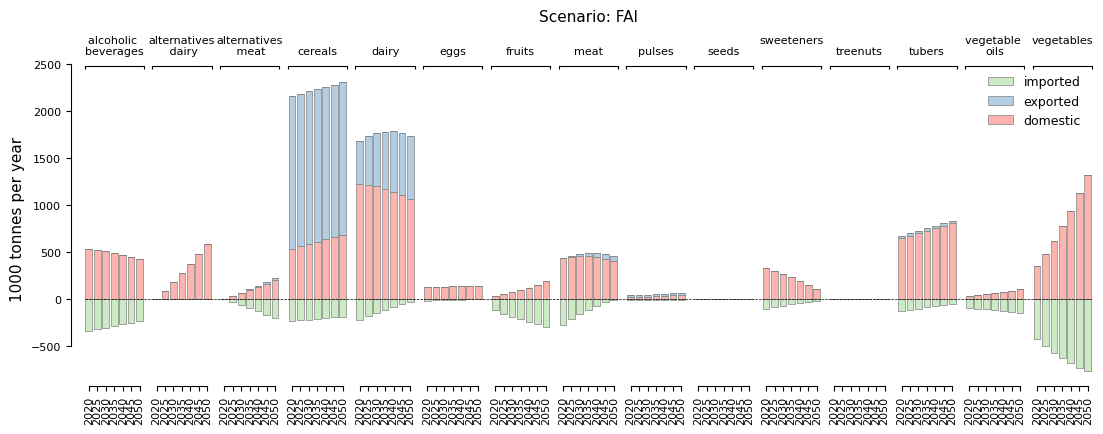

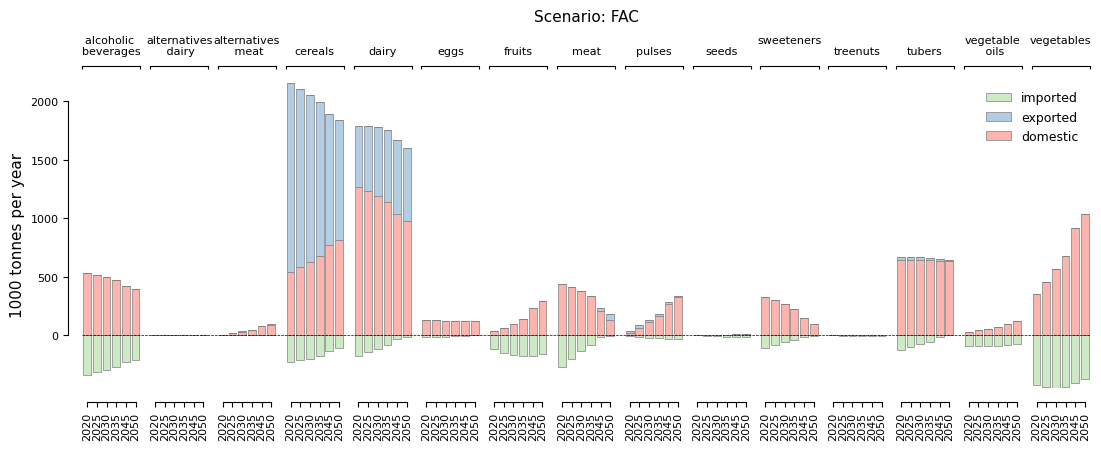

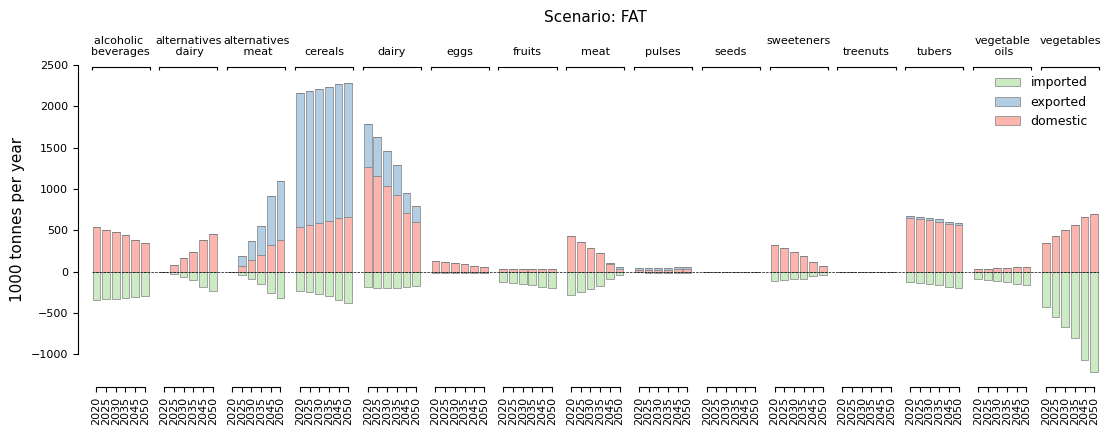

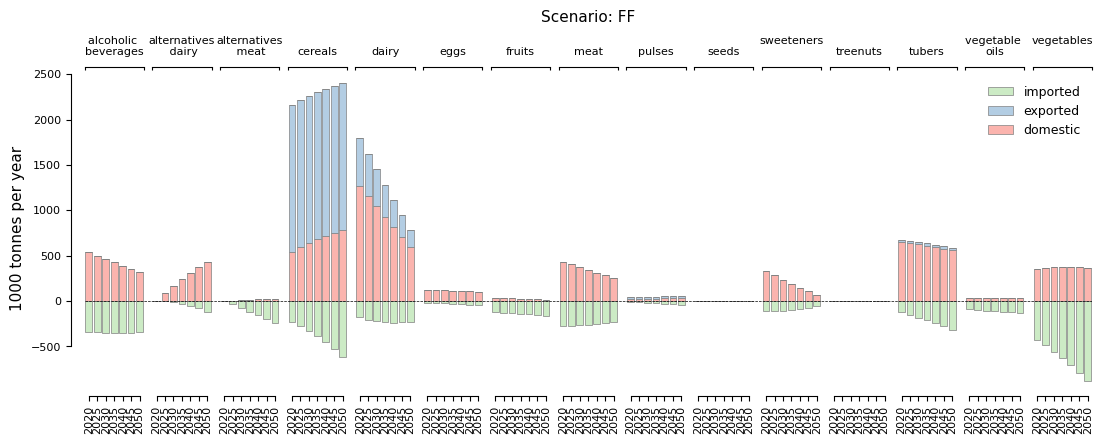

In [33]:
style = {
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'bar_width' : 0.8,
    'group_spacing' : 1,
    'grouplabels_fontsize' : 8,
    'ticklabels_fontsize' : 8,
    'totmarker' : 'none',
    'ylabel' : '1000 tonnes per year'
}
for scn in session.scenarios():
    fig, ax = plt.subplots(figsize=(13,4))
    cm.plot.bar(plot_data.loc[scn], group_levels='food_group', grouptitle=f'Scenario: {scn}', ax=ax, **style)
    plt.show()

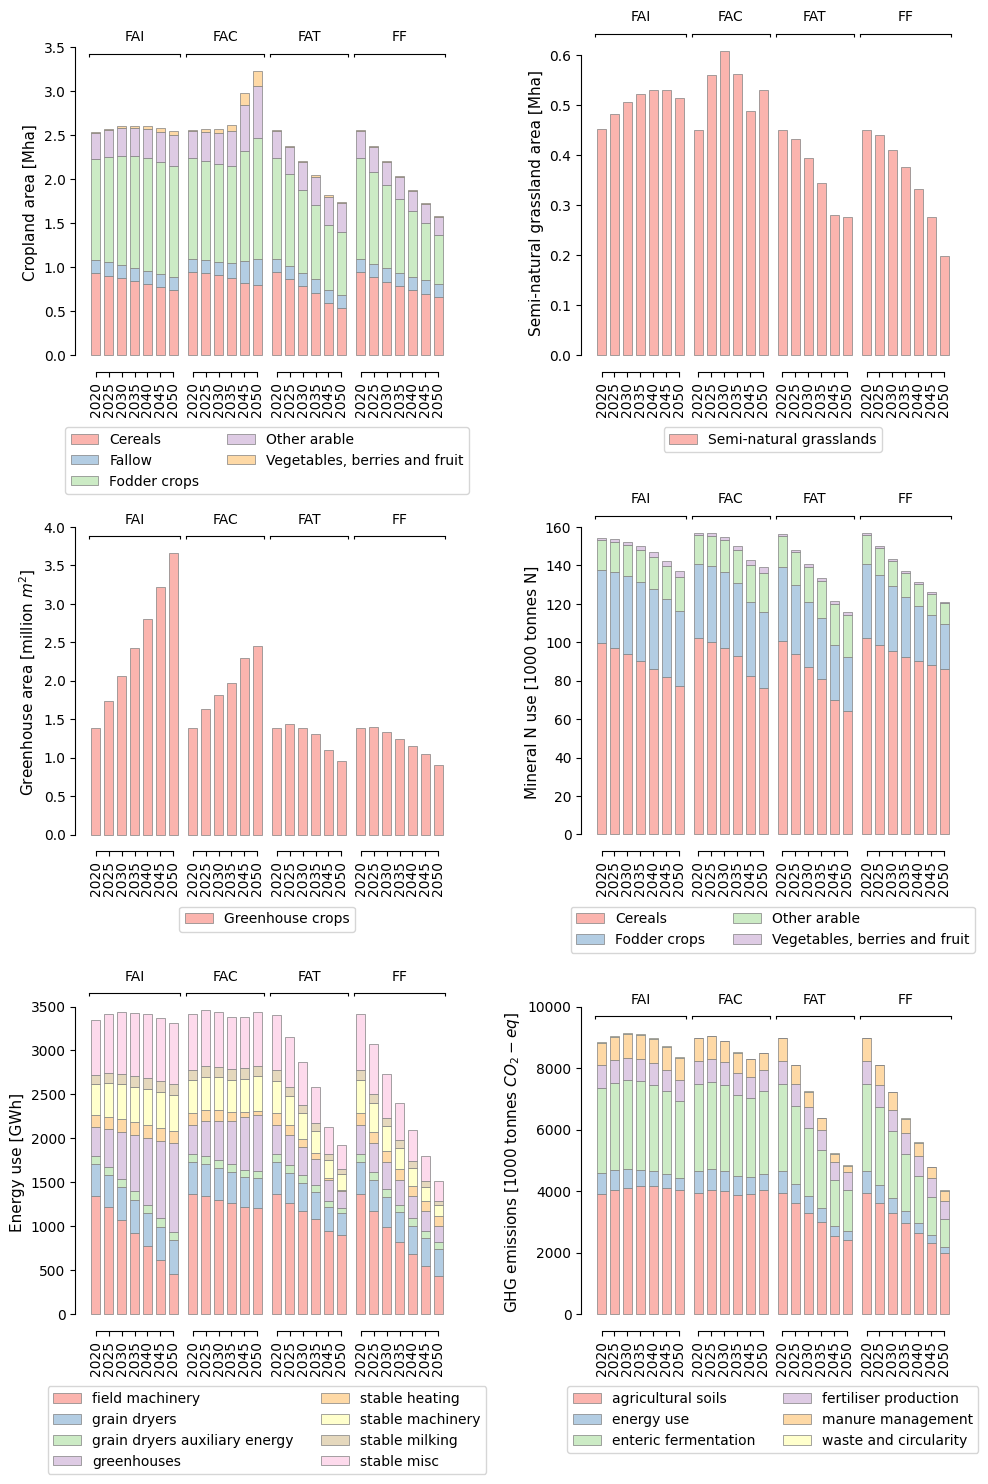

In [34]:
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'ticklabels_fontsize' : 8,
    'bar_width' : 0.7
}

fig, axs = plt.subplots(3,2, figsize=(10,15))

# Land use --->
plot_data = session.get_attr('C','area',{'crop':'crop_group2'})/1000000

# Cropland
ax = axs[0,0]
plot.bar(
    plot_data.drop(['Semi-natural grasslands','Greenhouse crops'], axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Cropland area [Mha]'
)

# Semi-natural grassland
ax = axs[0,1]
plot.bar(
    plot_data.xs('Semi-natural grasslands', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Semi-natural grassland area [Mha]'
)

# Greenhouse
ax = axs[1,0]
plot.bar(
    plot_data.xs('Greenhouse crops', axis=1),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'Greenhouse area [million $m^2$]'
)

# Mineral N use --->
ax = axs[1,1]
plot.bar(
    (session.get_attr('C','fertiliser.mineral_N',{'crop':'crop_group2'})/1000000),
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Mineral N use [1000 tonnes N]'
)

# Energy use --->
ax = axs[2,0]
plot.bar(
    pd.concat([
        session.get_attr('C','energy_use','activity'),
        session.get_attr('A','energy_use','activity')
    ], axis=1)/1000000,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel='Energy use [GWh]'
)

# GHG emissions
ax = axs[2,1]
plot_data = (
    cm.get_GHG(session)
    .T.groupby('process').sum().T
)/1000000
plot.bar(
    plot_data,
    **style,
    ax=ax,
    group_levels='scn',
    ylabel=r'GHG emissions [1000 tonnes $CO_{2}-eq$]'
)

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.2), fontsize=10)

plt.tight_layout()
plt.show()

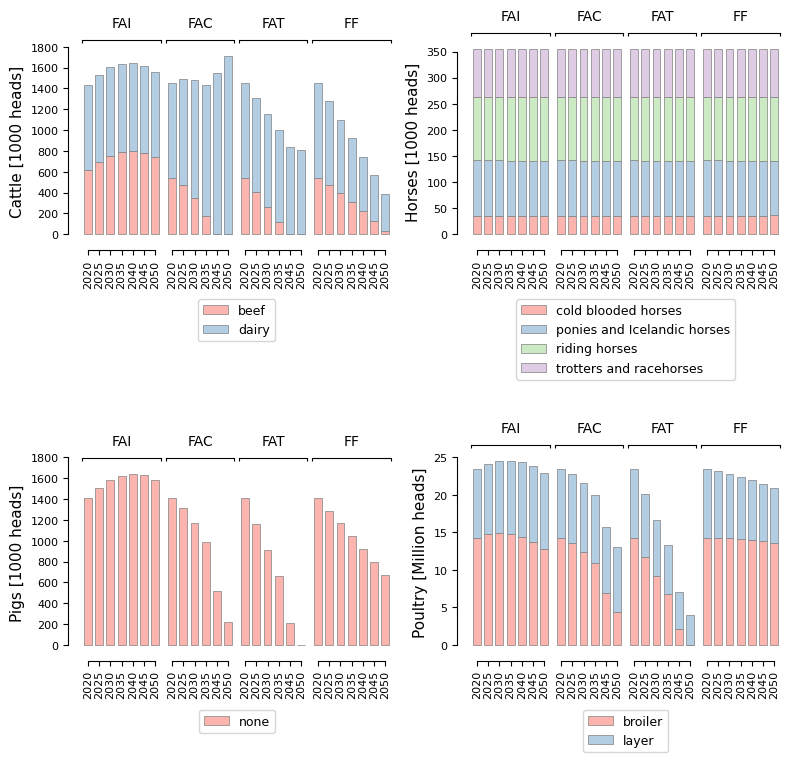

CPU times: total: 1.66 s
Wall time: 1.94 s


In [43]:
%%time
style = {
    'stacked' : True,
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey',
    'ticklabels_fontsize' : 8,
    'bar_width' : 0.7,
    
}
    
# Number of animal heads
plot_data = session.get_attr('A','heads',['species','breed'])

fig, axs = plt.subplots(2,2, figsize=(8,8))

for ax,sp in zip(axs.flatten(),plot_data.columns.get_level_values('species').unique()):

    plot.bar(
        (plot_data / (1000000 if sp=='poultry' else 1000))
        .xs(sp, level='species', axis=1),
        **style,
        ax=ax,
        group_levels='scn',
        ylabel=sp.capitalize() + (' [Million heads]' if sp=='poultry' else ' [1000 heads]')
    )

    # ax.legend(loc='lower left', bbox_to_anchor=(0, 0))

for ax in axs.flatten():
    ax.legend(loc='upper center', ncol=1, bbox_to_anchor=(0.5, -0.3), fontsize=9)

plt.tight_layout()
plt.show()

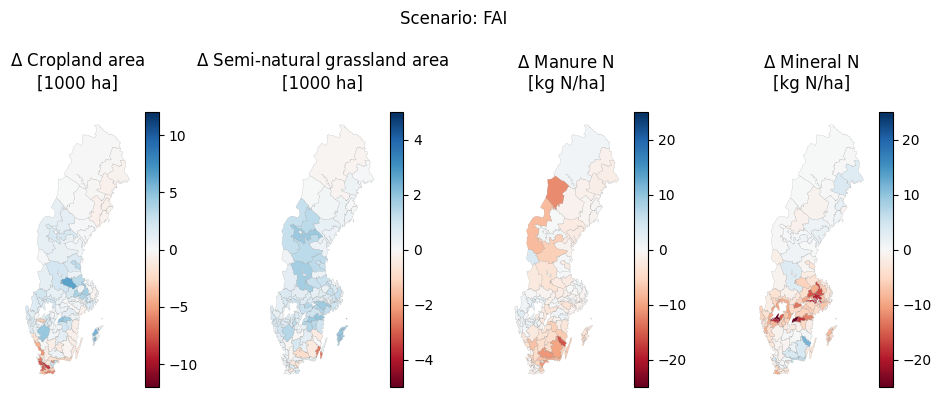

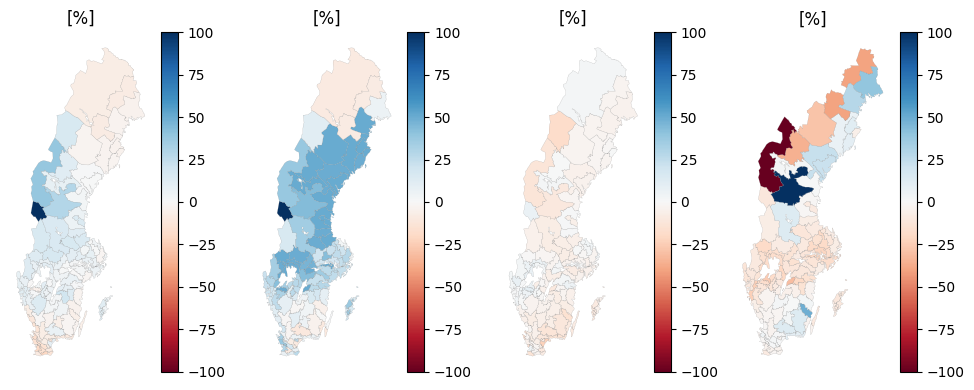

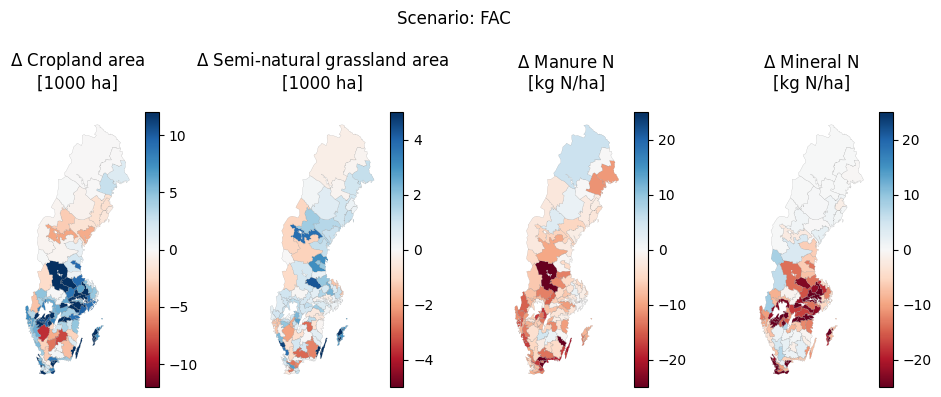

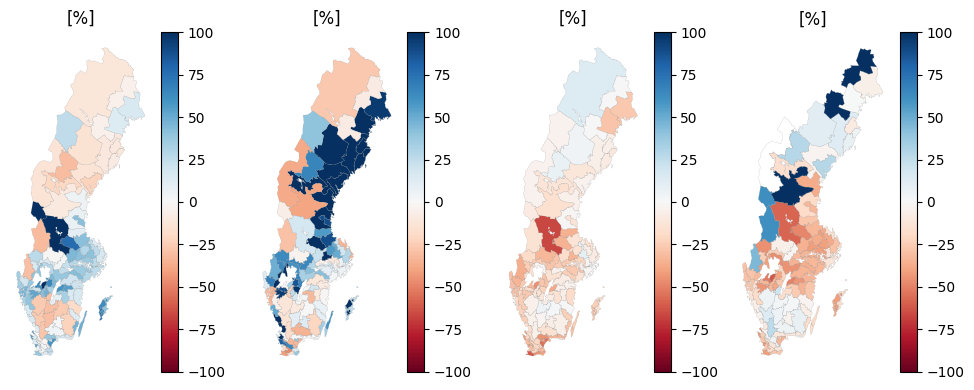

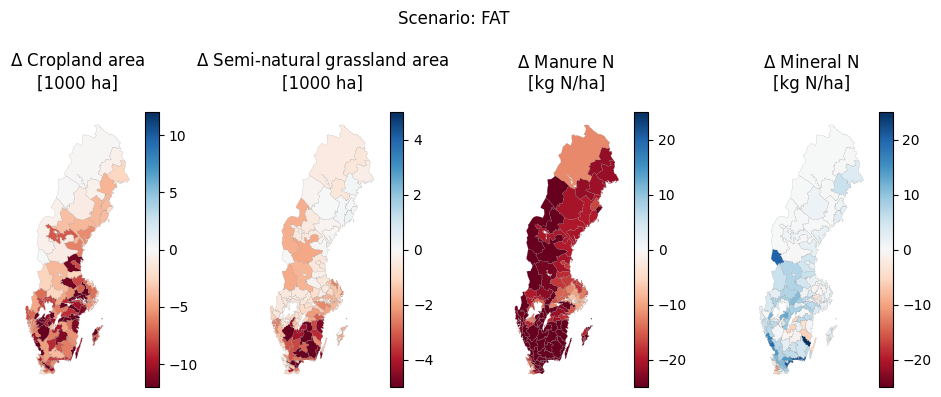

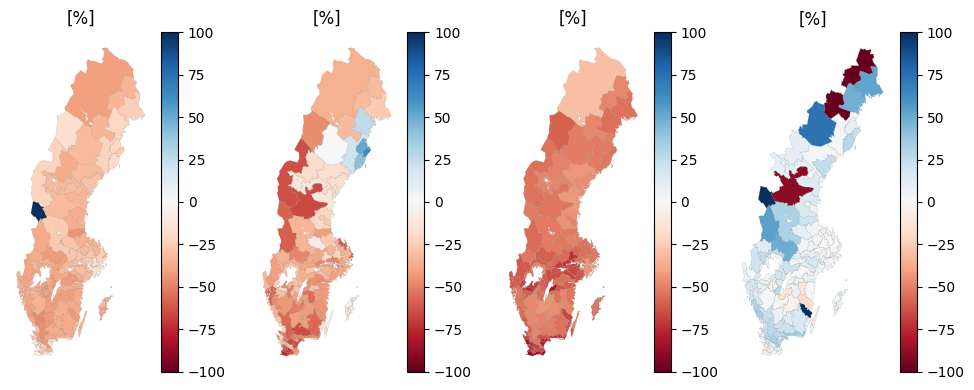

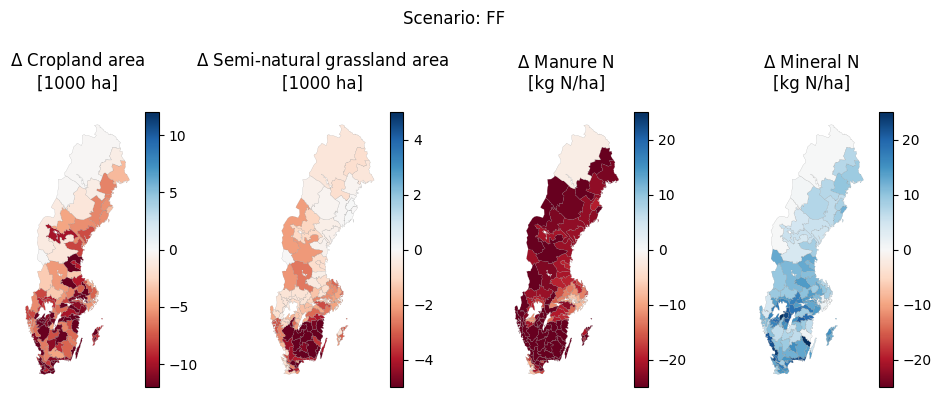

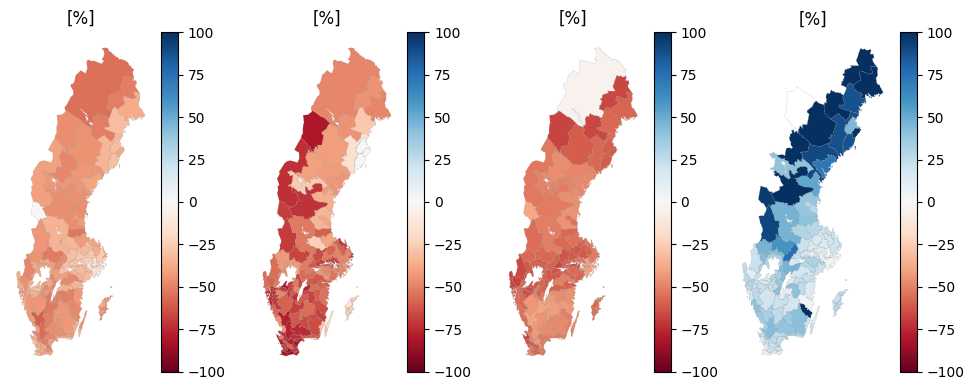

CPU times: total: 5.39 s
Wall time: 6.11 s


In [48]:
%%time
for scn in session.scenarios():
    
    y0 = session.scenarios()[scn][0]
    yend = session.scenarios()[scn][-1]

    # ABSOLUTE
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-12,
        vmax=12,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Cropland area\n[1000 ha]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-5,
        vmax=5,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Semi-natural grassland area\n[1000 ha]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Manure N \n[kg N/ha]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = plot_data.loc[yend] - plot_data.loc[y0]
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-25,
        vmax=25,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('$\Delta$ Mineral N \n[kg N/ha]')
    ax.set_axis_off()

    
    plt.suptitle(f'Scenario: {scn}')
    plt.tight_layout()
    plt.show()

    # PERCENT
    fig, axs = plt.subplots(1,4, figsize=(10,4))
    
    # LAND USE -------->
    plot_data = session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn]/1000
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    # Cropland area --->
    ax = axs[0]
    plot.map_from_series(
        plot_data.loc['cropland'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Grassland area --->
    ax = axs[1]
    plot.map_from_series(
        plot_data.loc['semi-natural grasslands'],
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Manure N application --->
    plot_data = session.get_attr('C','fertiliser.manure_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[2]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()

    # Mineral N application --->
    plot_data = session.get_attr('C','fertiliser.mineral_N',{'crop':'land_use','region':None}).loc[scn,'cropland'] \
    / session.get_attr('C','area',{'crop':'land_use','region':None}).loc[scn,'cropland']
    plot_data = (plot_data.loc[yend] - plot_data.loc[y0]) / plot_data.loc[y0] * 100
    
    ax = axs[3]
    plot.map_from_series(
        plot_data,
        cmap='RdBu',
        vmin=-100,
        vmax=100,
        edgecolor='grey',
        ax=ax
    )
    ax.set_title('[%]')
    ax.set_axis_off()
   
    
    plt.tight_layout()
    plt.show()

FAI
---


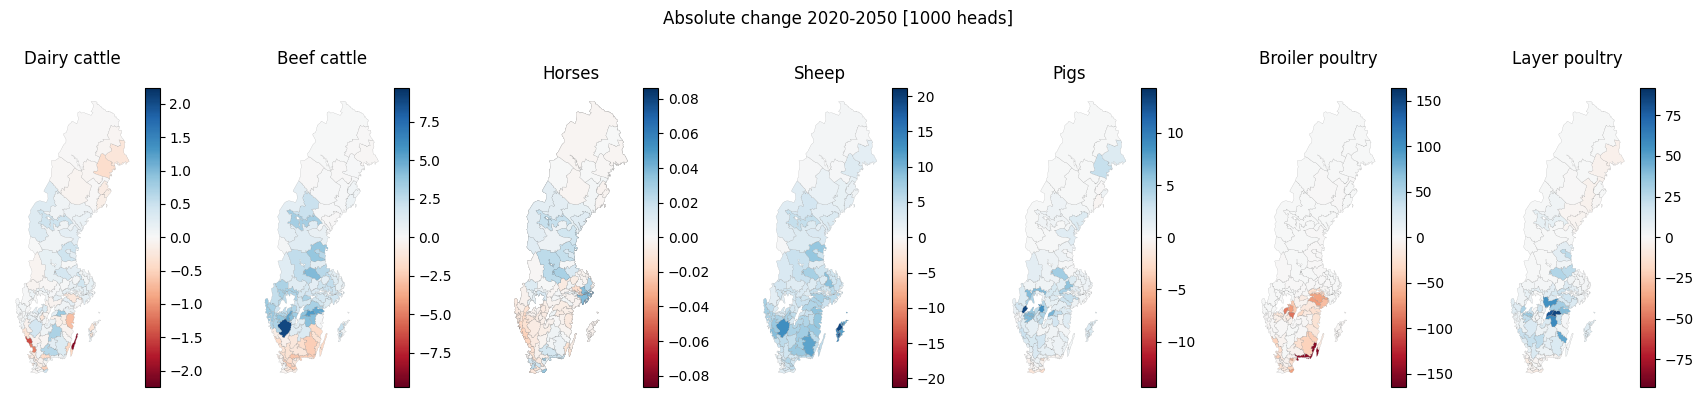

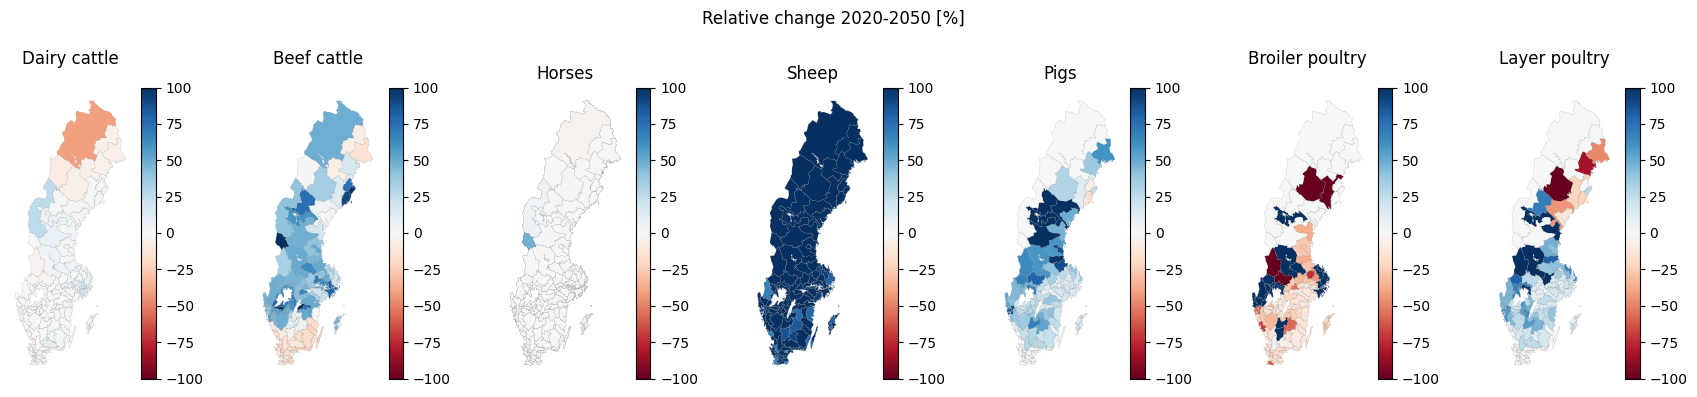

FAC
---


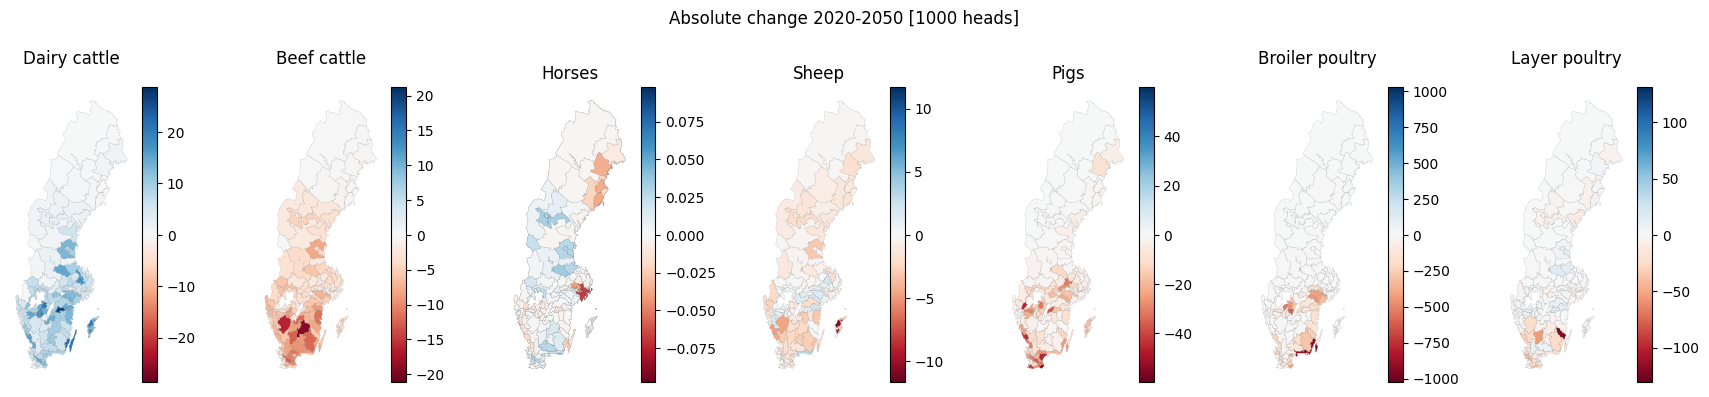

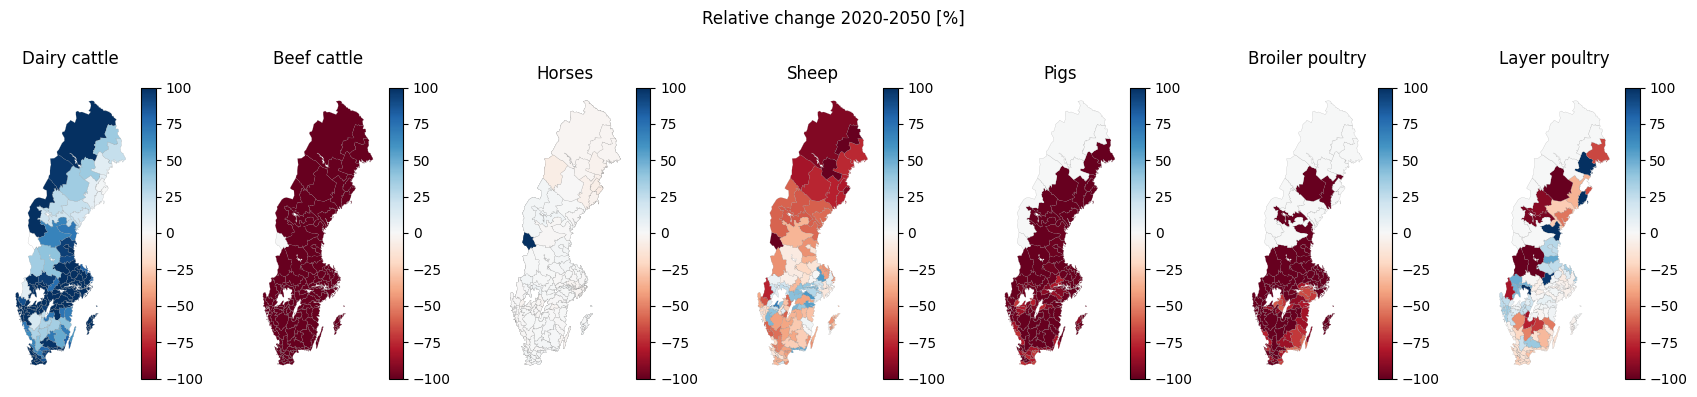

FAT
---


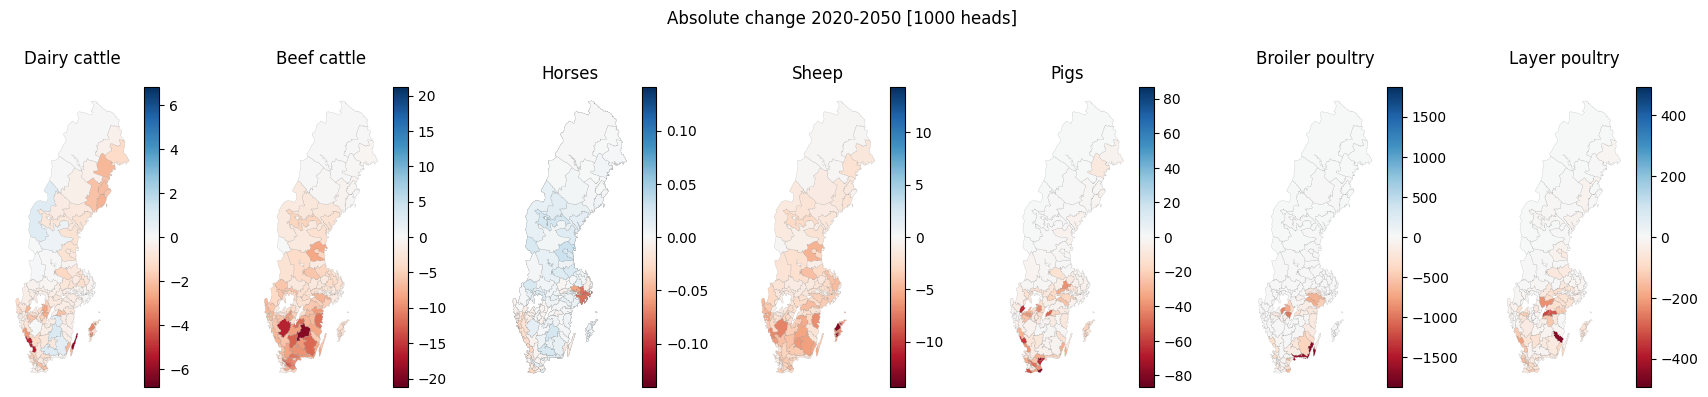

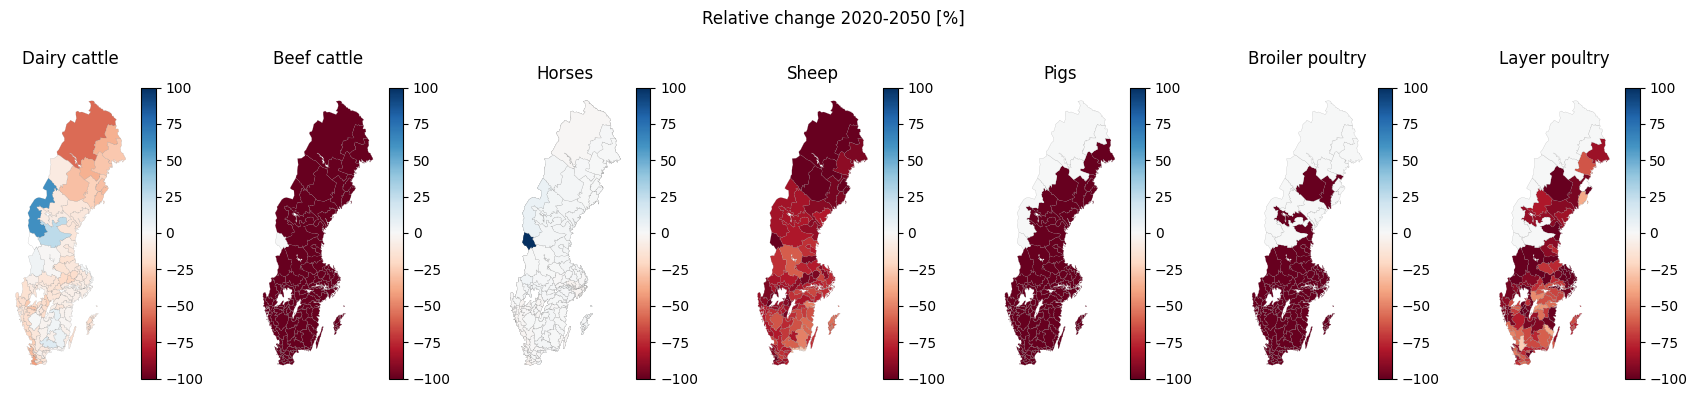

FF
--


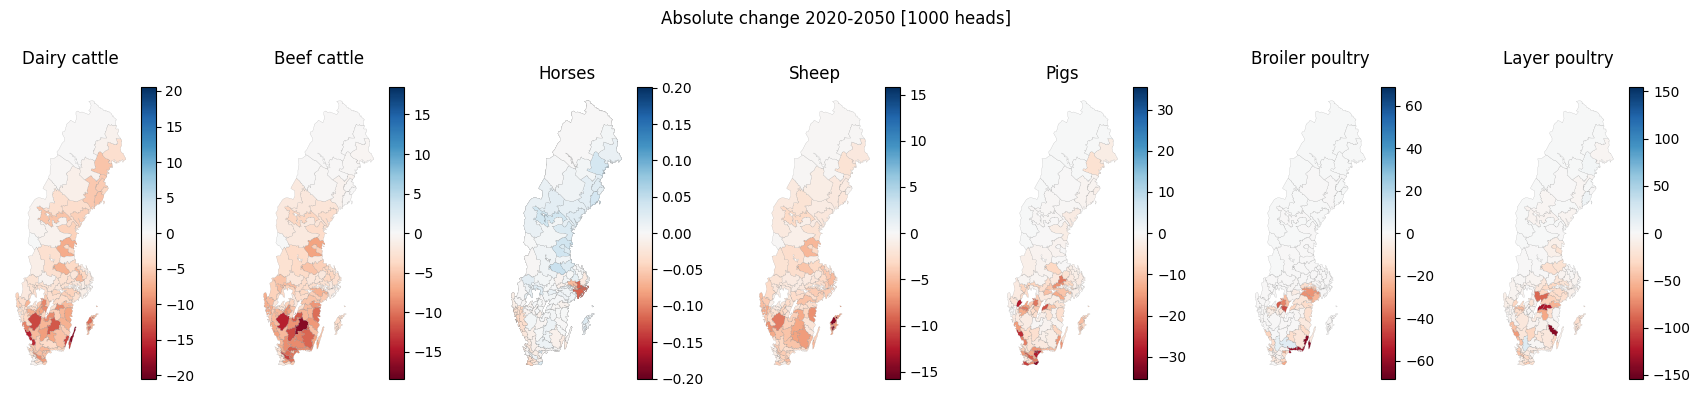

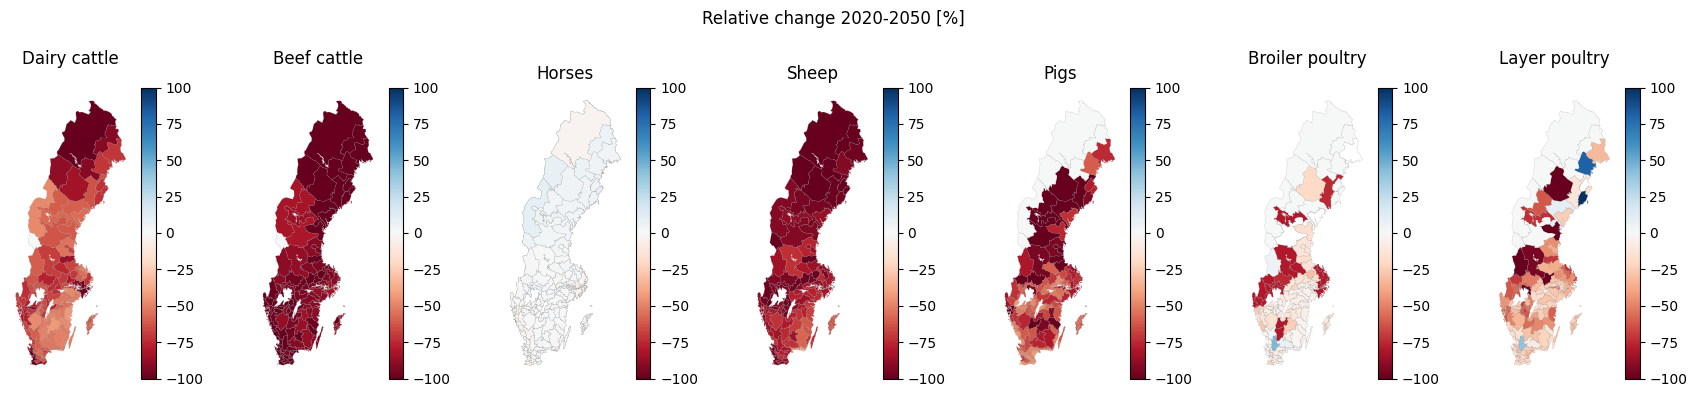

CPU times: total: 15.7 s
Wall time: 17.2 s


In [49]:
%%time
selection = {
    'Dairy cattle':('cattle','dairy'),
    'Beef cattle':('cattle','beef'),
    'Horses':('horses',slice(None)),
    'Sheep':('sheep',slice(None)),
    'Pigs':('pigs',slice(None)),
    'Broiler poultry':('poultry','broiler'),
    'Layer poultry':('poultry','layer')
}

for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data = session.get_attr('A','heads',['species','breed','region']).loc[scn]/1000
    plot_data_abs = (plot_data.loc['2050'] - plot_data.loc['2020']).sort_index()
    plot_data_prc = ((plot_data.loc['2050'] - plot_data.loc['2020']) / plot_data.loc['2020'] * 100).sort_index().fillna(0)
    
    # ABSOLUTE
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_abs.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-lim*1.1,
            vmax=lim*1.1,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)  
    plt.suptitle('Absolute change 2020-2050 [1000 heads]')
    plt.tight_layout()
    plt.show()
    
    # PERCENT
    fig, axs = plt.subplots(1,len(selection), figsize=(len(selection)*2.5,4))
    for ax,sel in zip(axs,selection):
        d = plot_data_prc.loc[selection[sel]]
        lim = max(abs(d))
        plot.map_from_series(
            d,
            ax=ax,
            cmap='RdBu',
            vmin=-100,
            vmax=100,
            edgecolor='grey'
        )
        ax.axis('off')
        ax.set_title(sel)
    plt.suptitle('Relative change 2020-2050 [%]')
    plt.tight_layout()
    plt.show()

### Detailed changes across regions
Here are some plots that show how changes in the scenarios are distributed across regions by the optimisation algorithm implemented in the `GeoDistributor`.

FAI
---


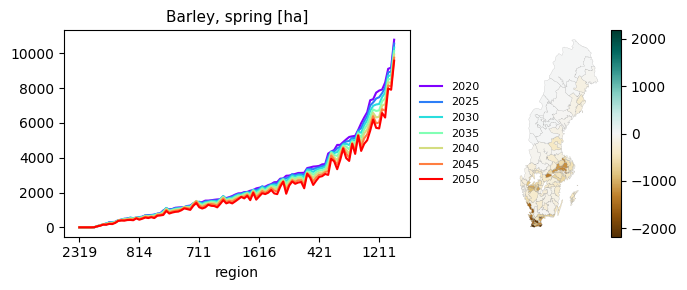

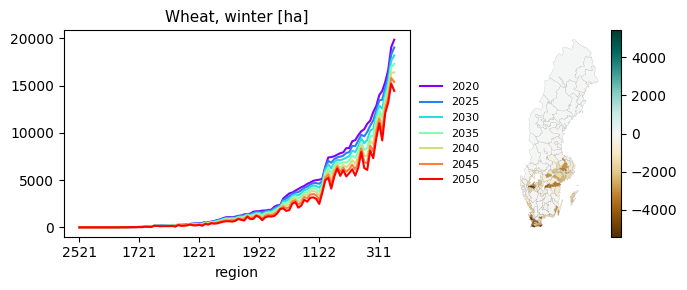

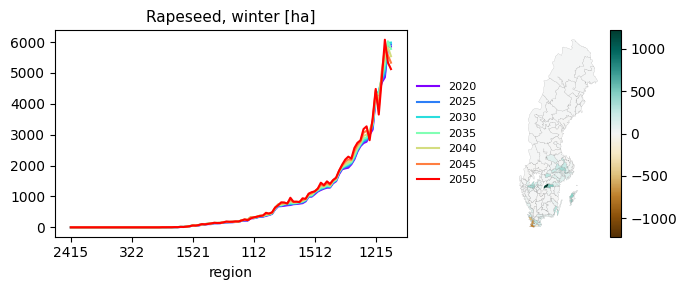

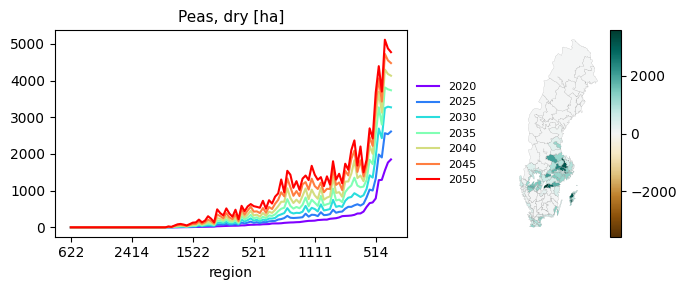

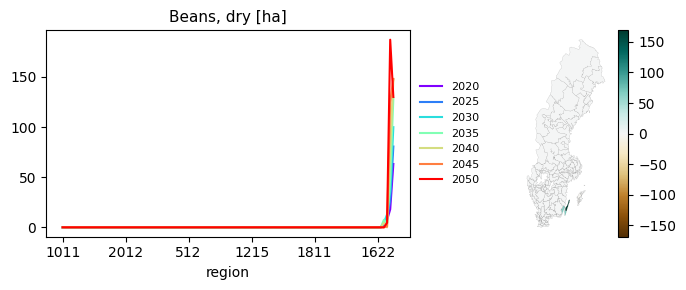

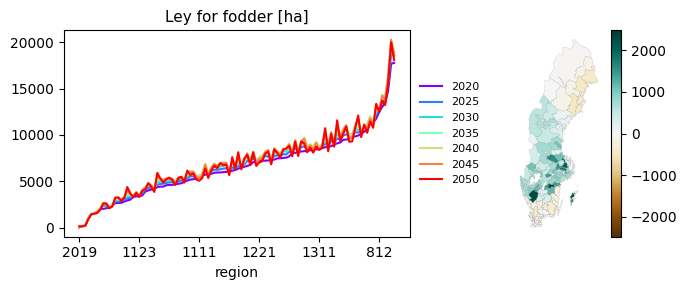

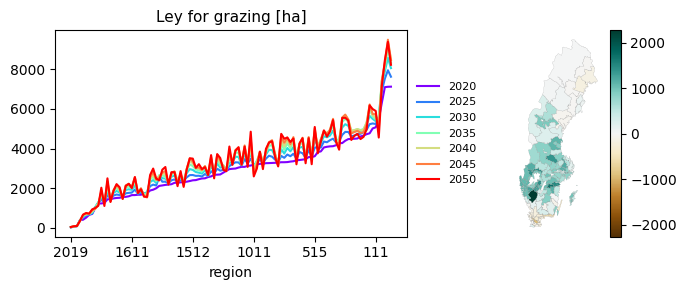

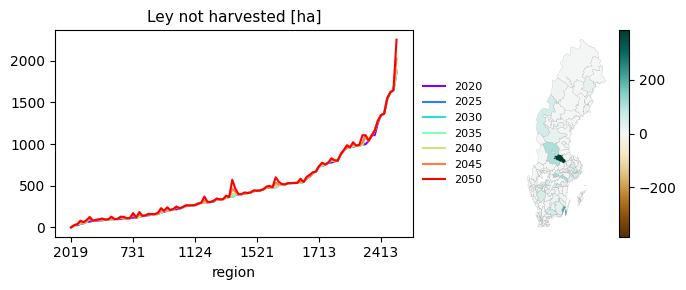

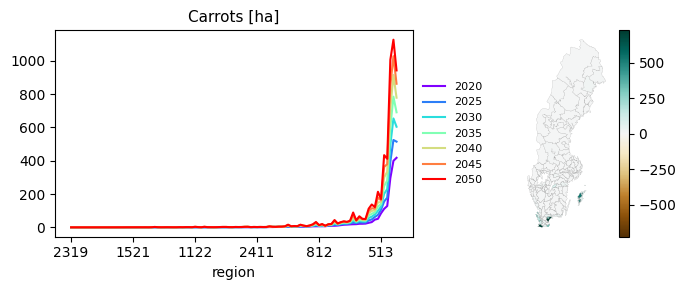

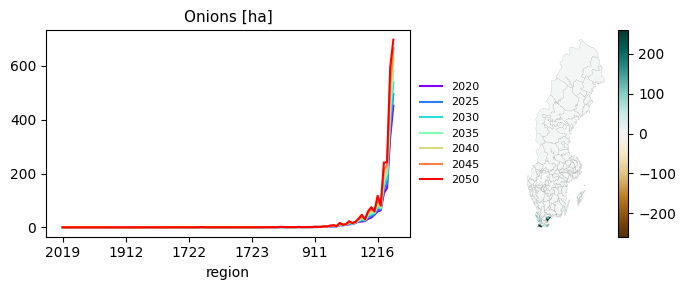

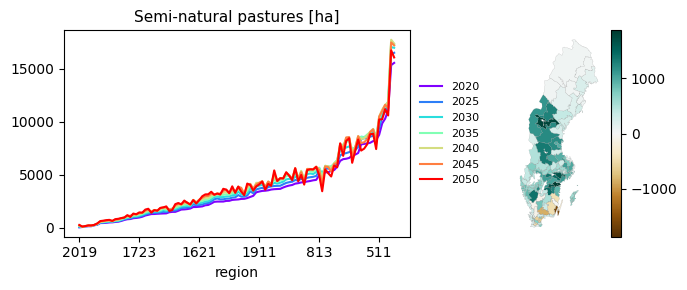

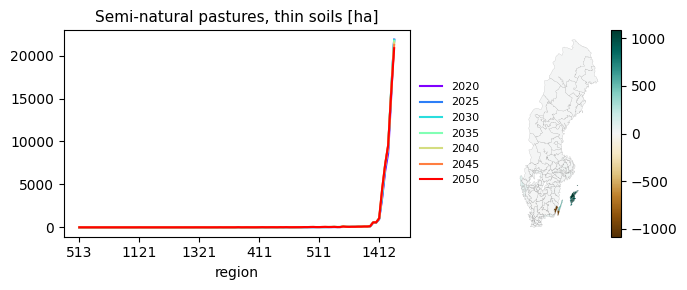

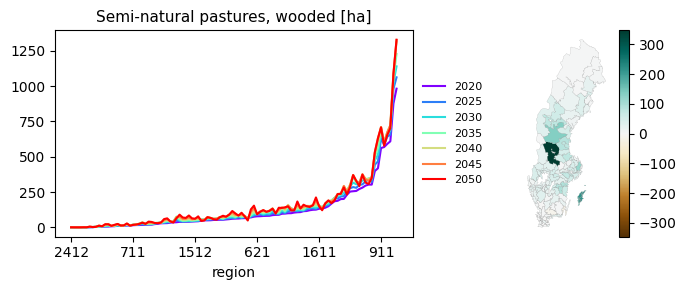

FAC
---


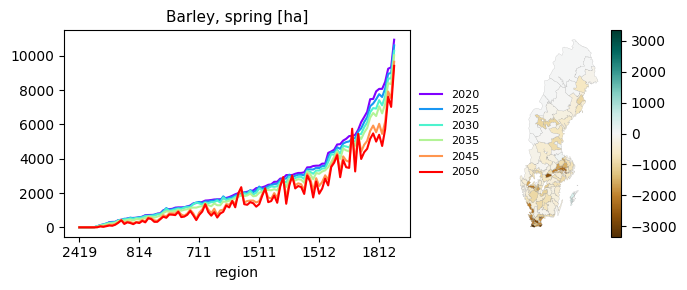

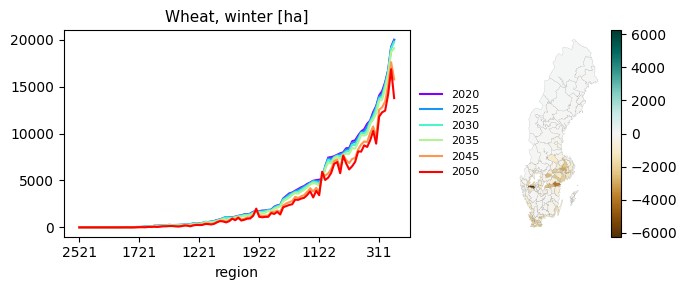

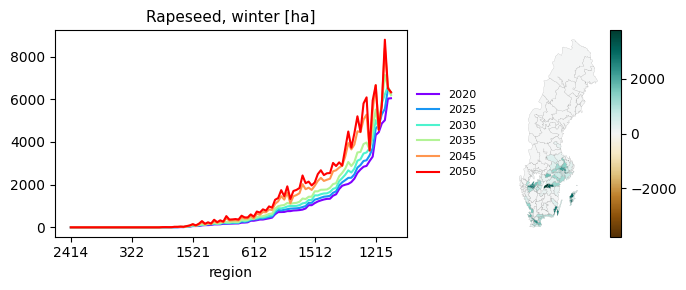

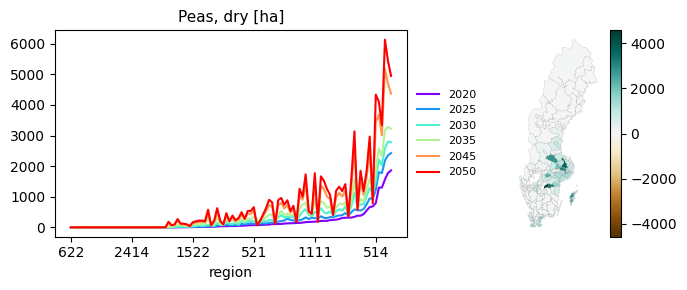

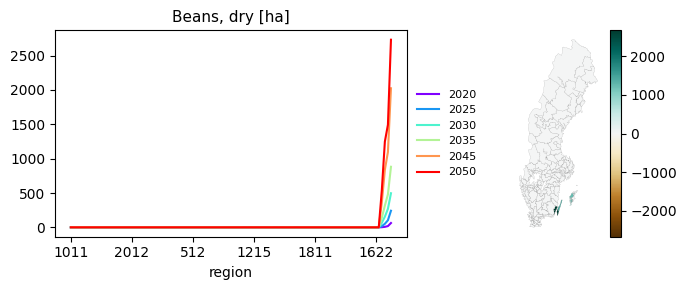

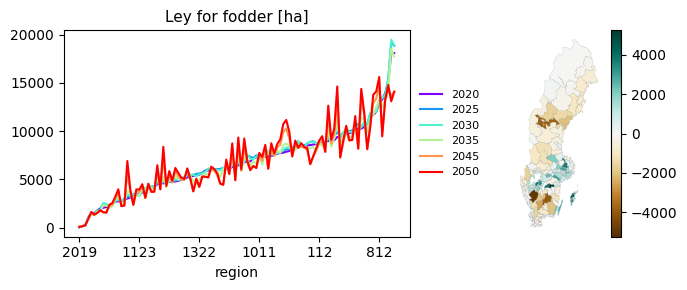

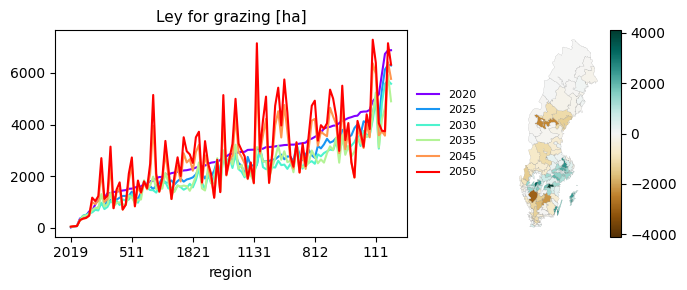

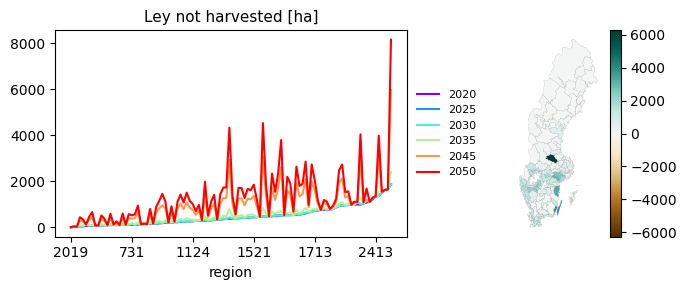

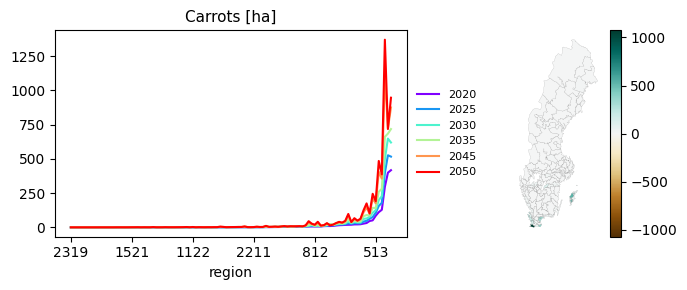

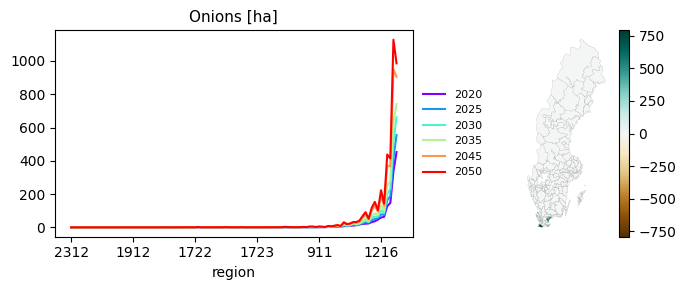

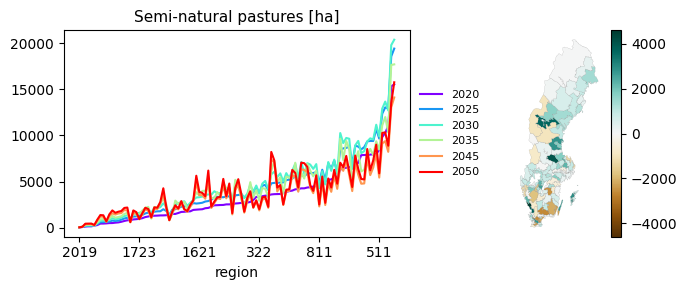

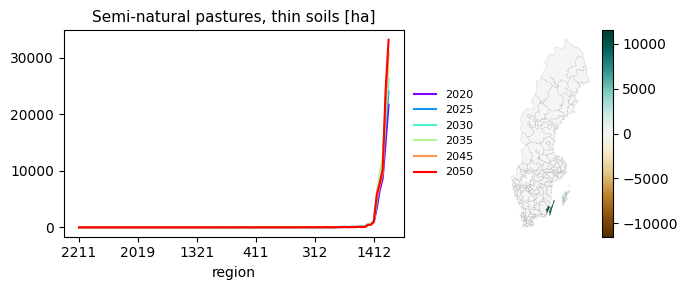

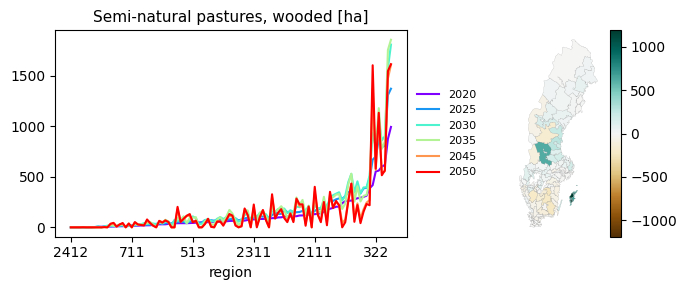

FAT
---


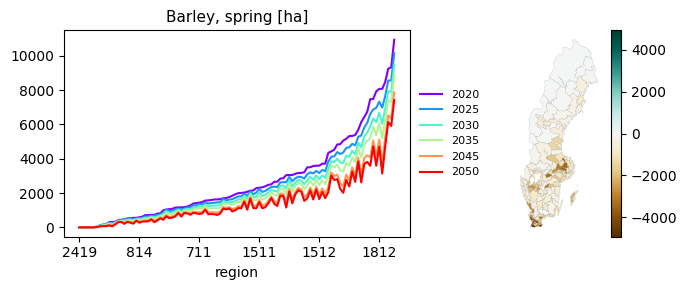

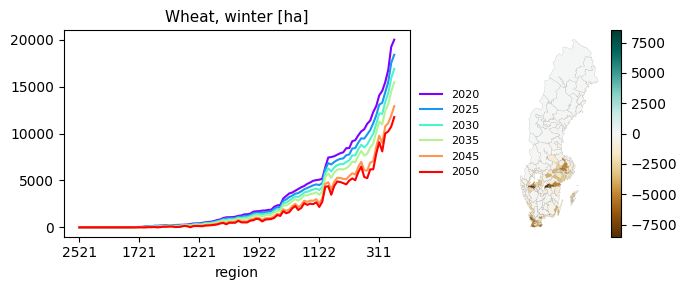

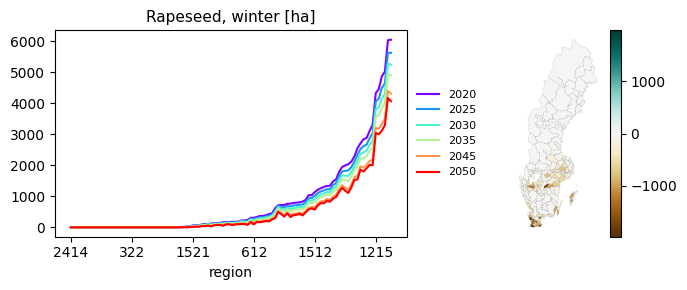

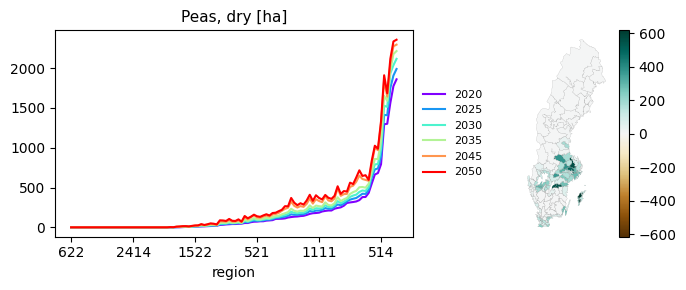

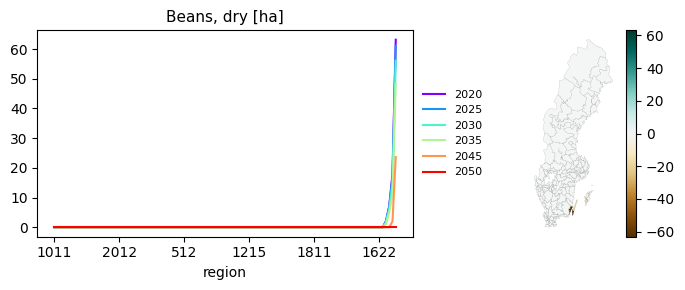

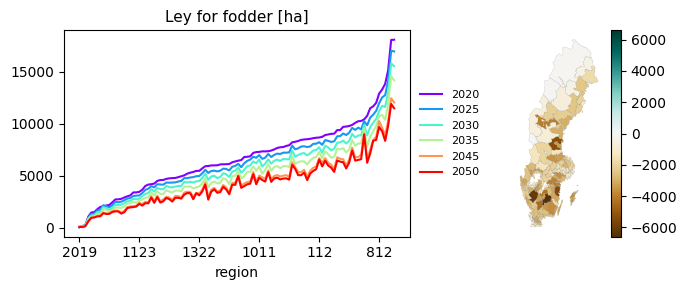

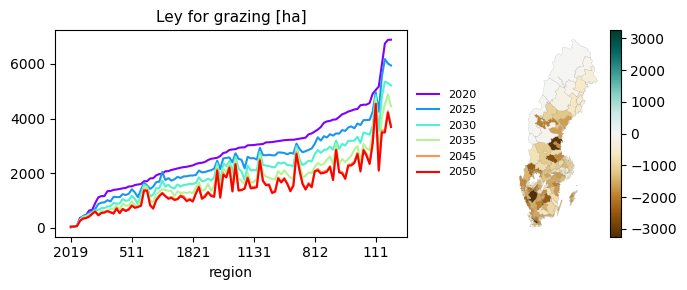

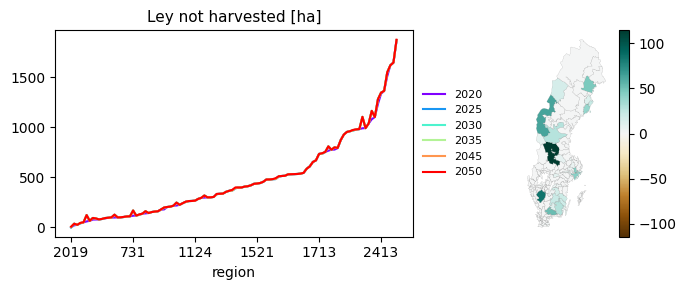

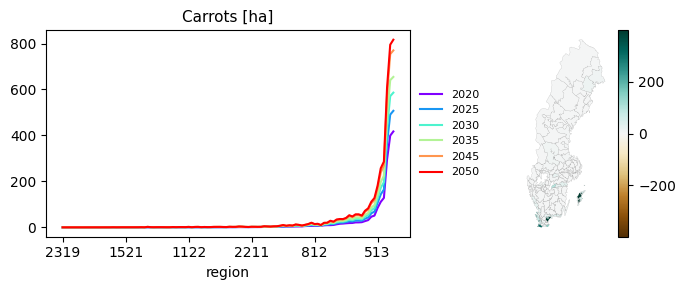

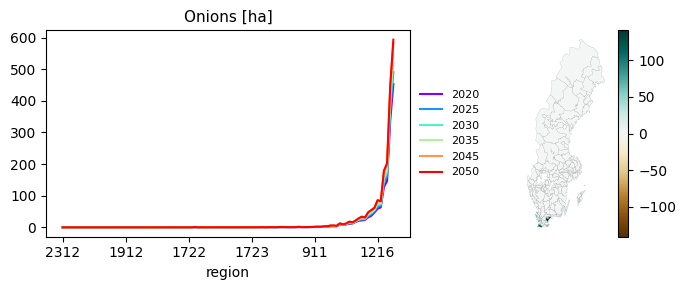

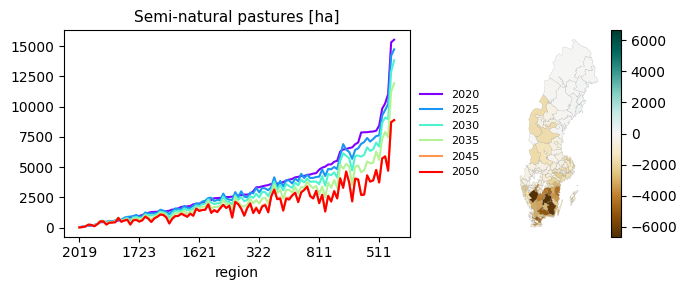

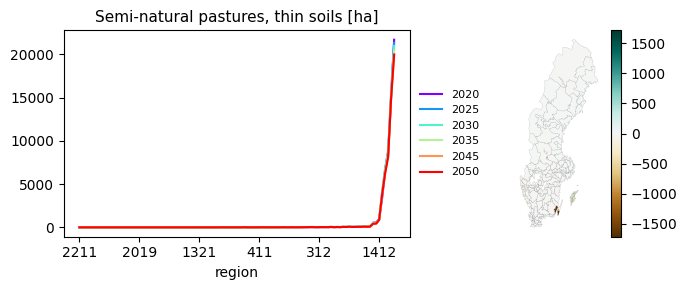

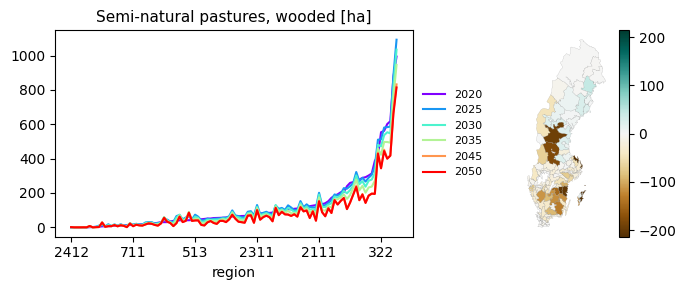

FF
--


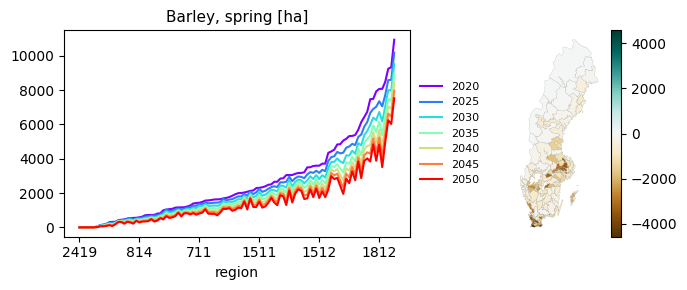

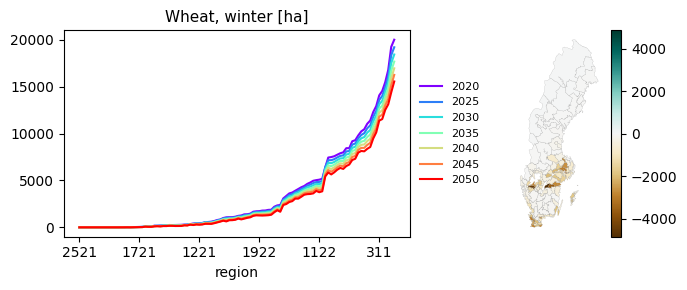

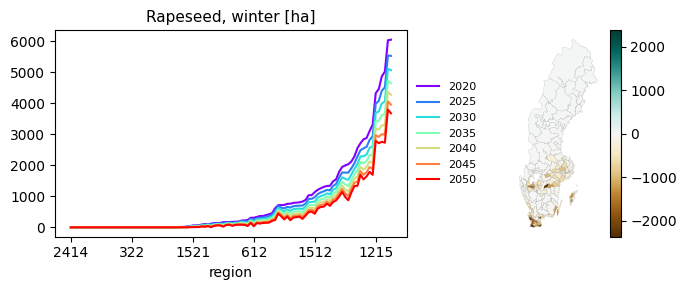

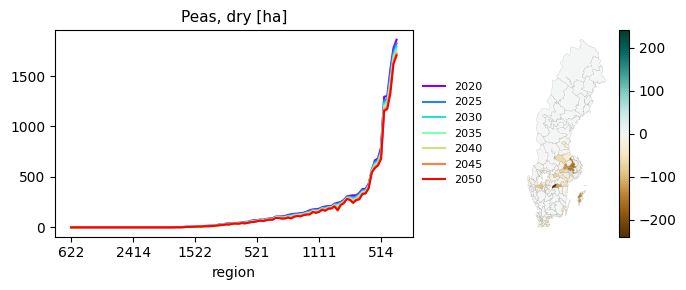

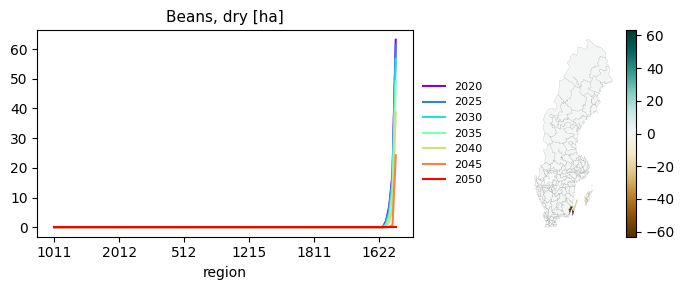

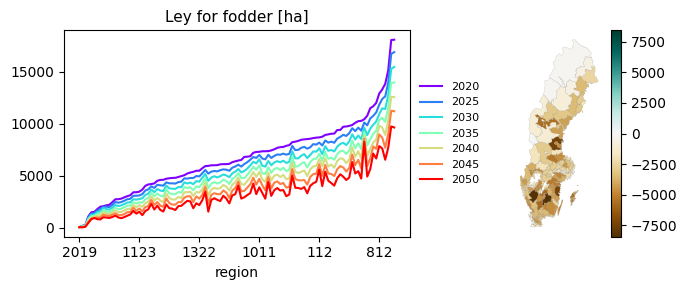

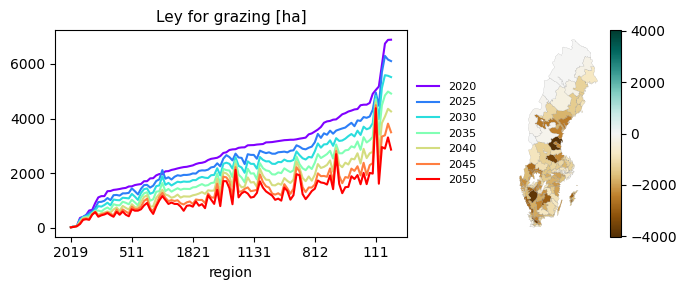

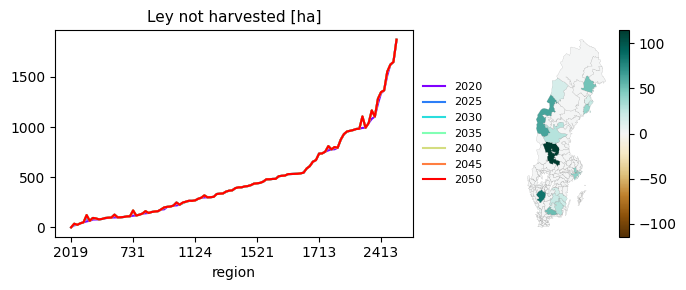

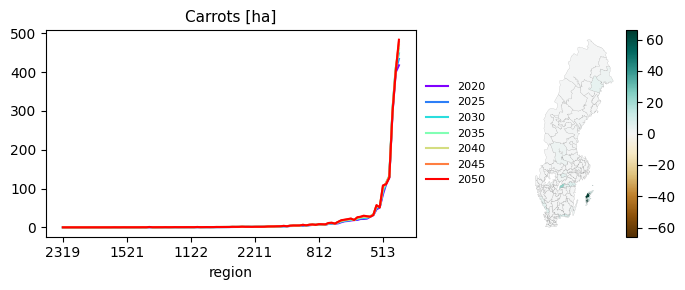

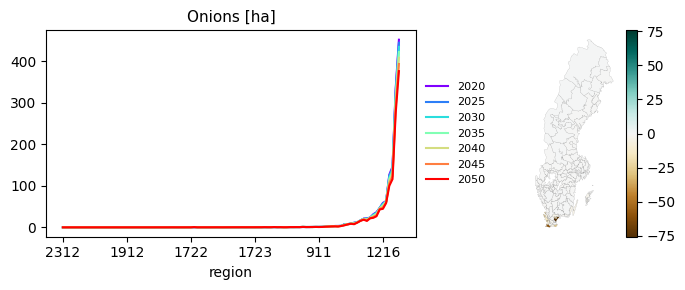

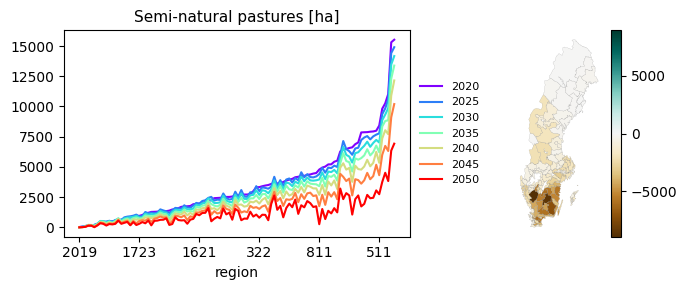

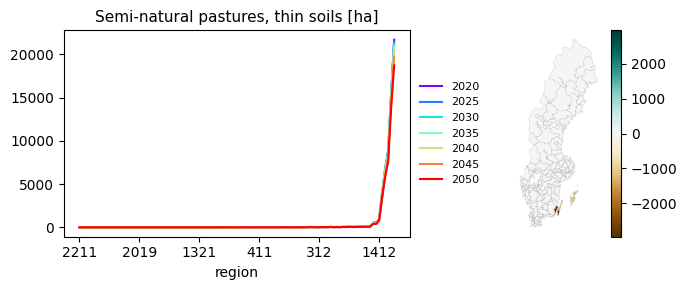

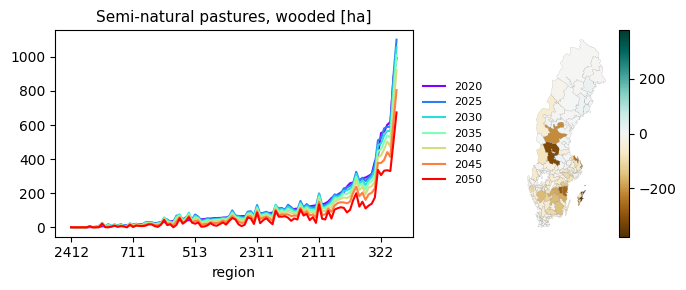

In [54]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    
    plot_data_ = session.get_attr('C','area',['crop','region'], scn=scn).droplevel('scn').T
    years = list(plot_data_.columns)
    crps = ['Barley, spring','Wheat, winter',
            'Rapeseed, winter',
            'Peas, dry', 'Beans, dry',
            'Ley for fodder','Ley for grazing', 'Ley not harvested',
            'Carrots','Onions',
            'Semi-natural pastures','Semi-natural pastures, thin soils','Semi-natural pastures, wooded']
    for crp in crps:
        plot_data = plot_data_.loc[crp].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(crp+' [ha]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

FAI
---


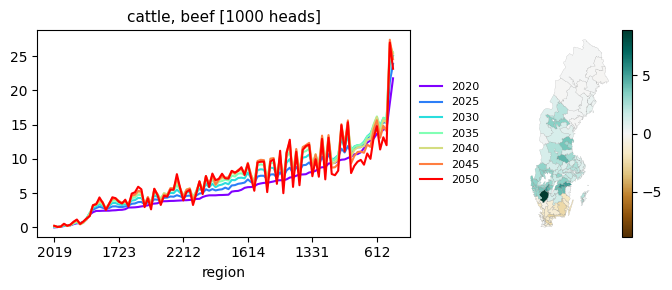

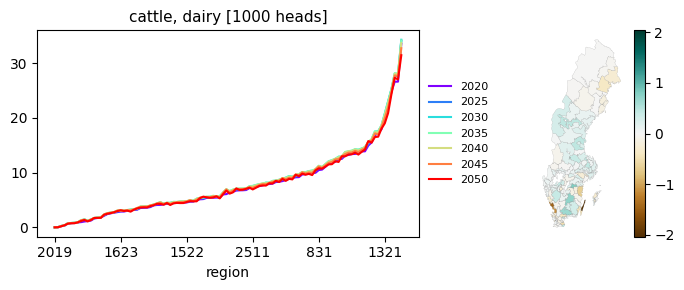

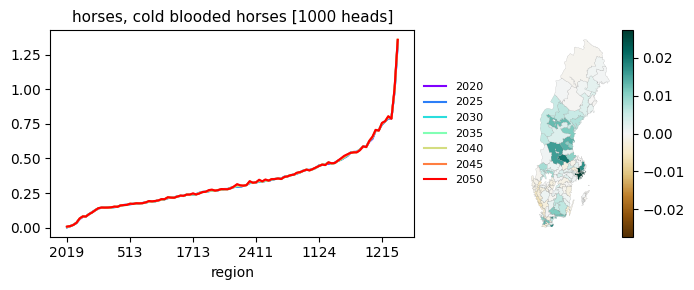

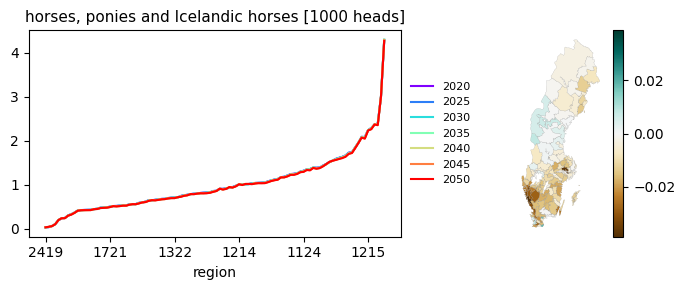

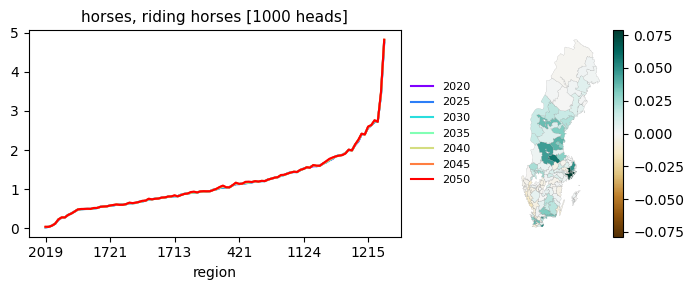

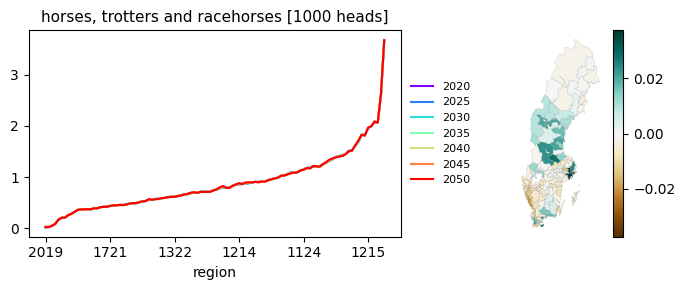

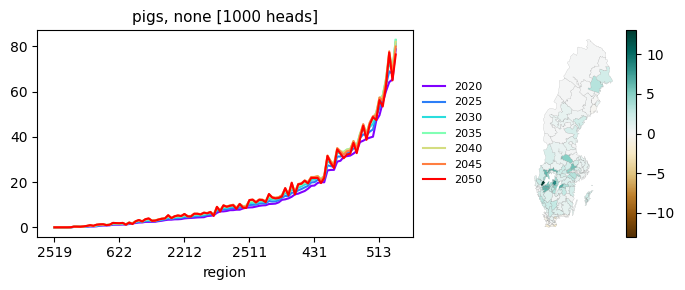

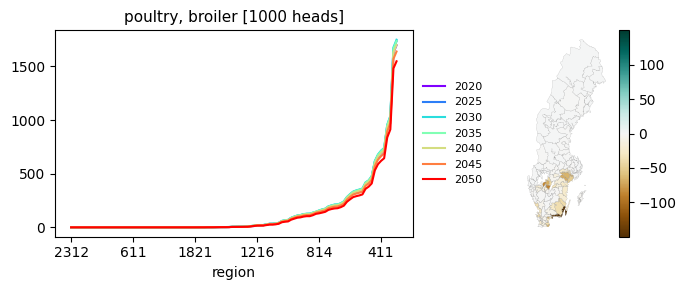

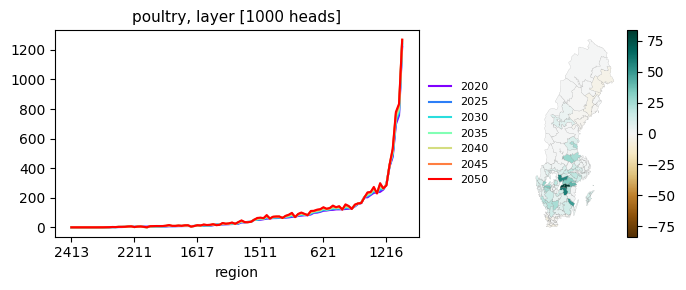

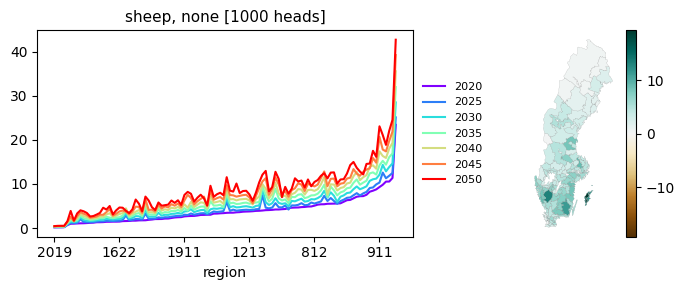

FAC
---


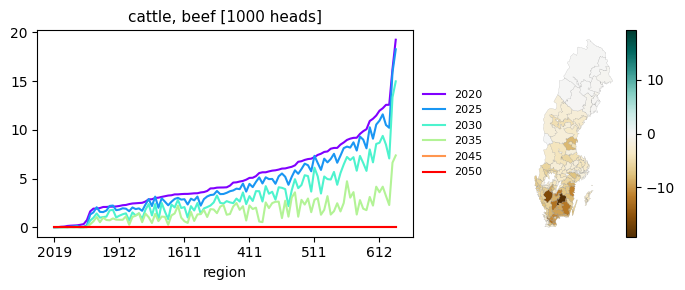

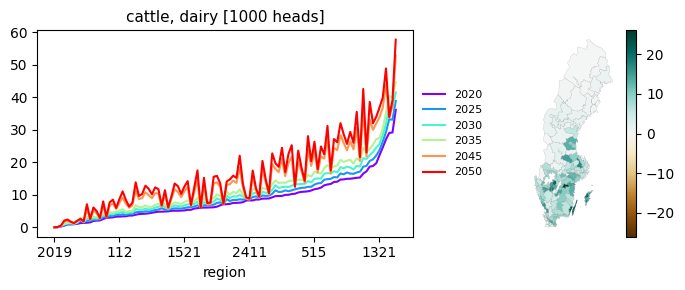

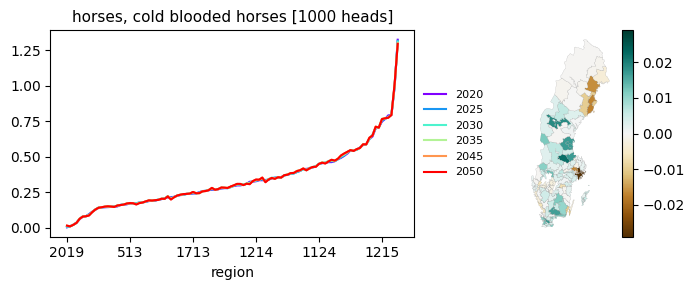

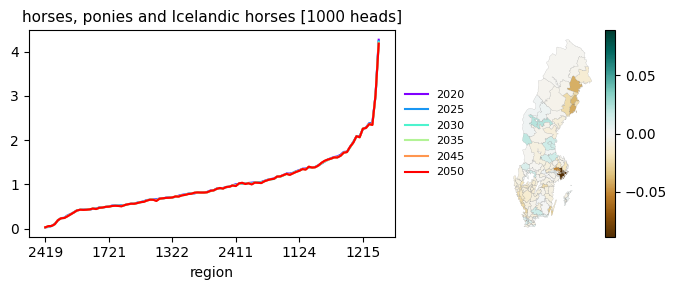

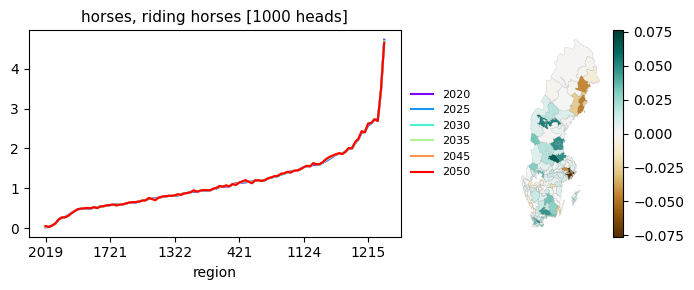

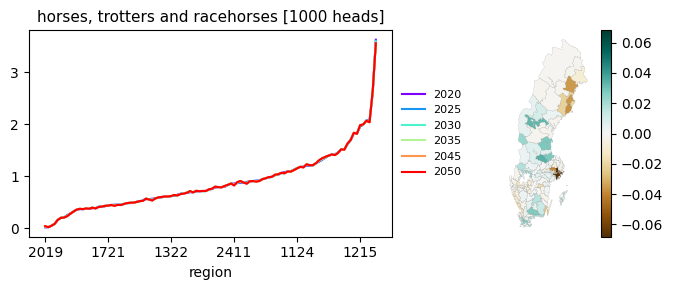

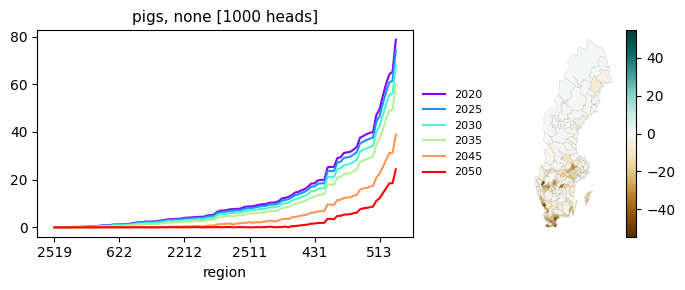

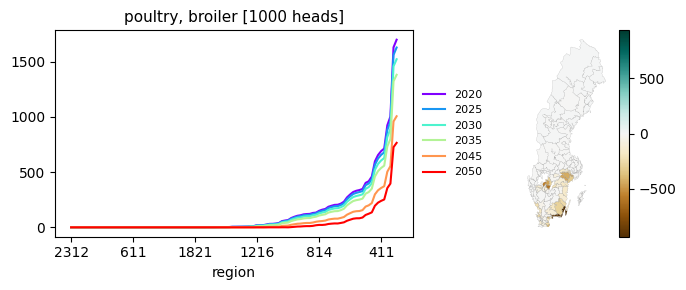

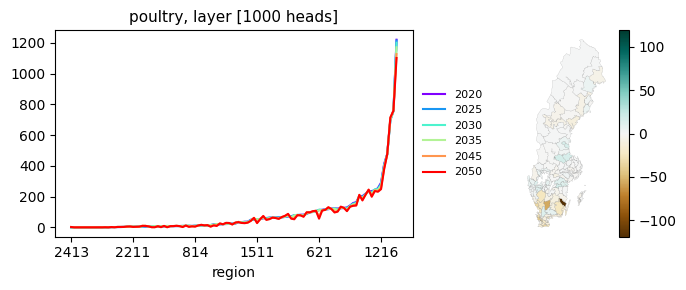

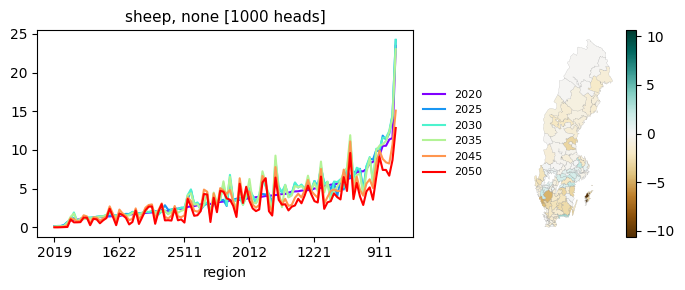

FAT
---


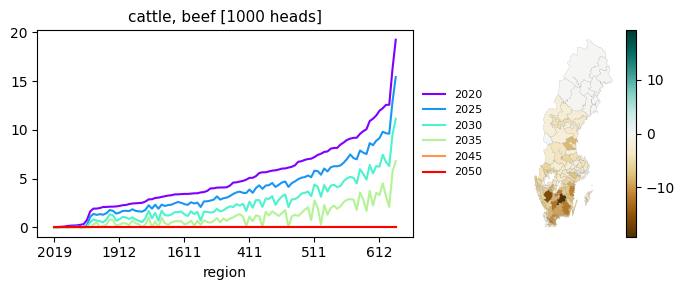

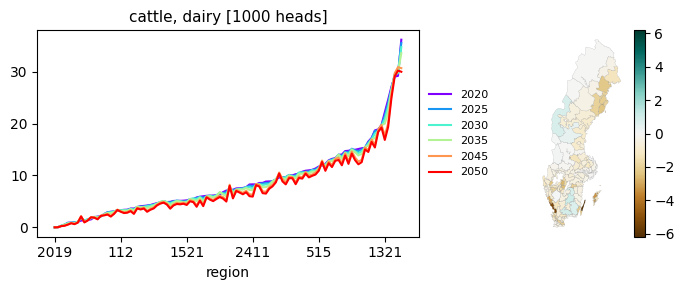

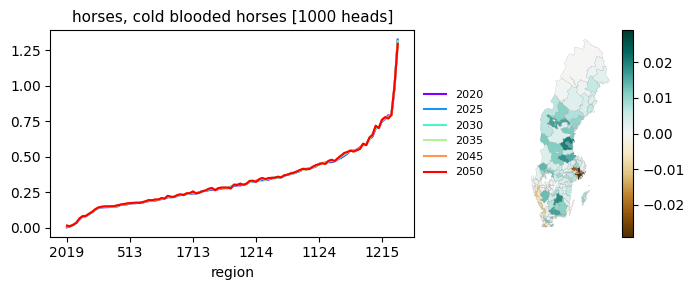

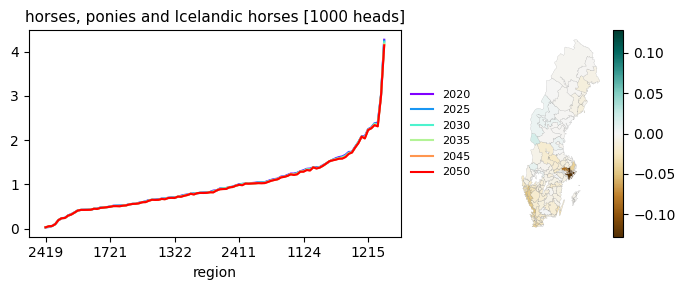

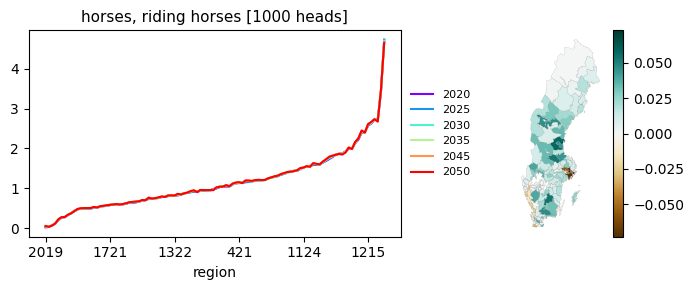

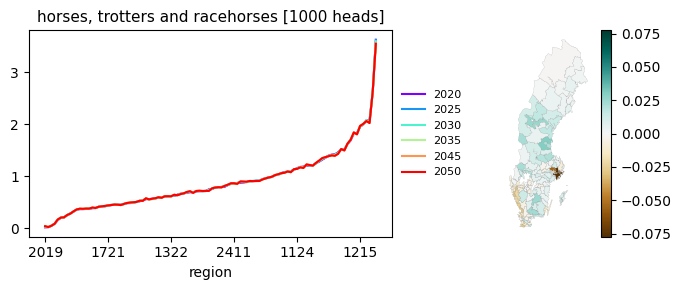

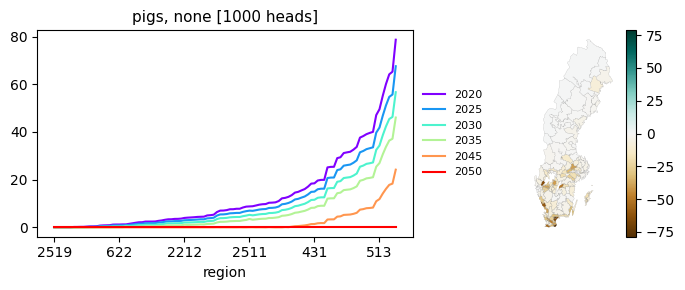

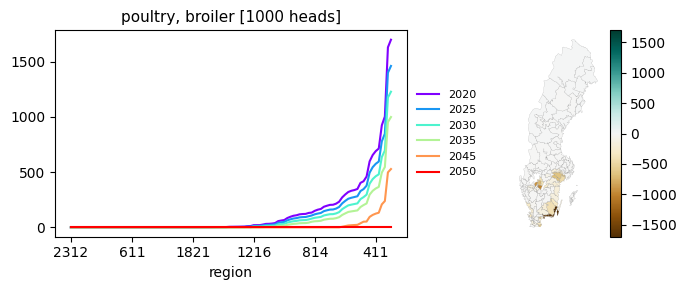

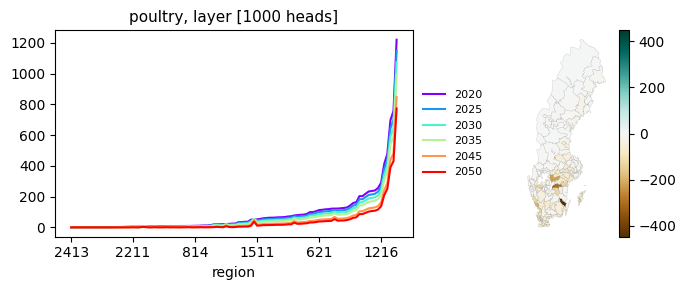

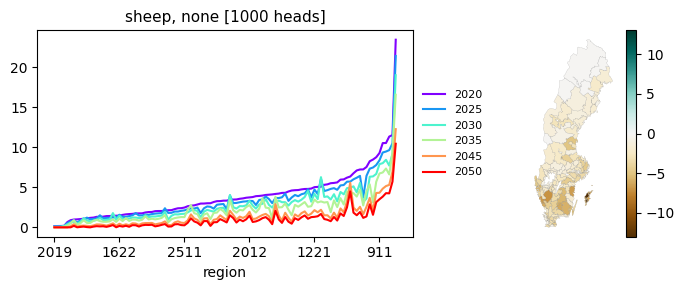

FF
--


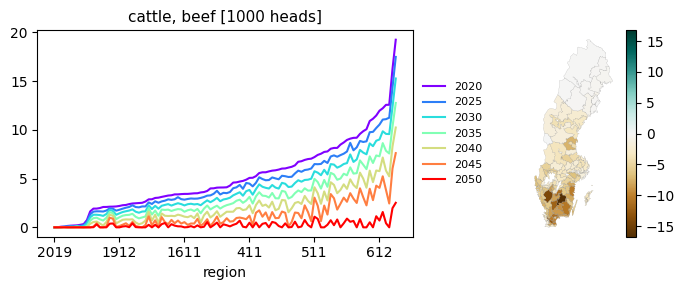

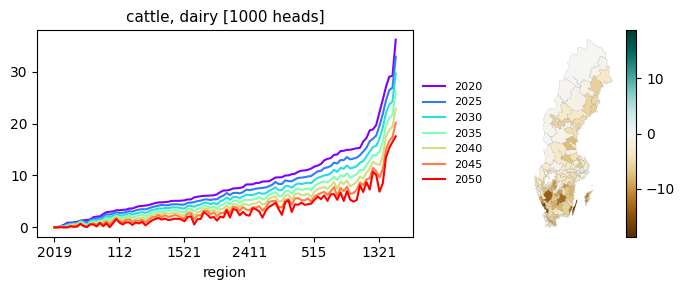

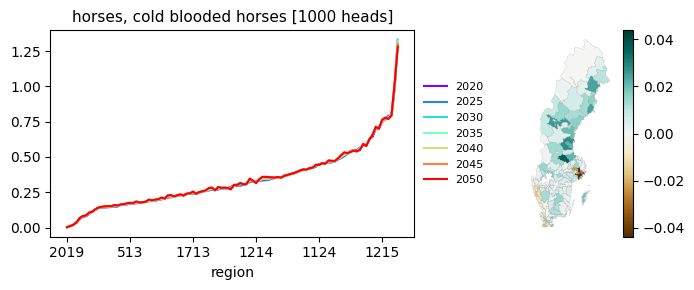

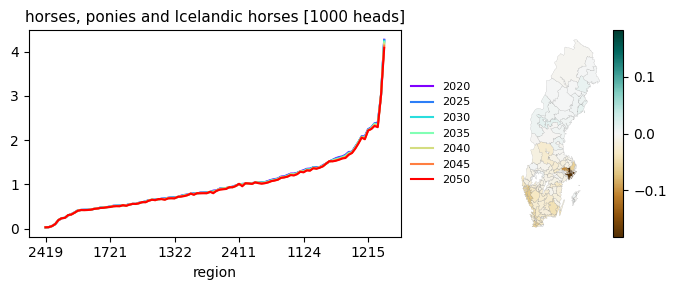

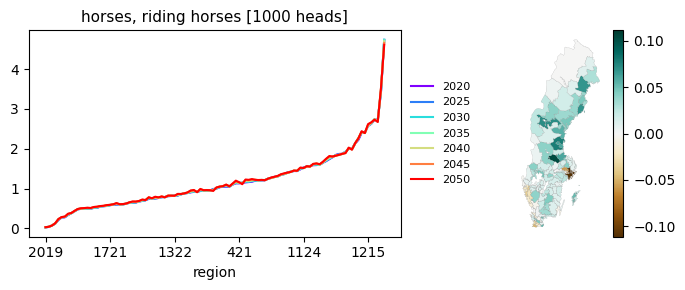

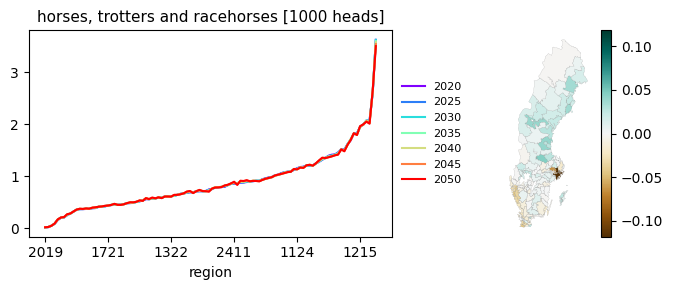

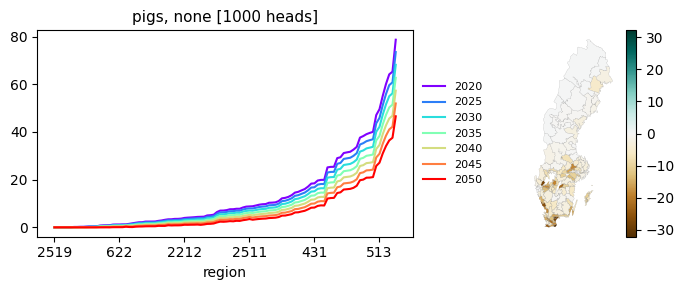

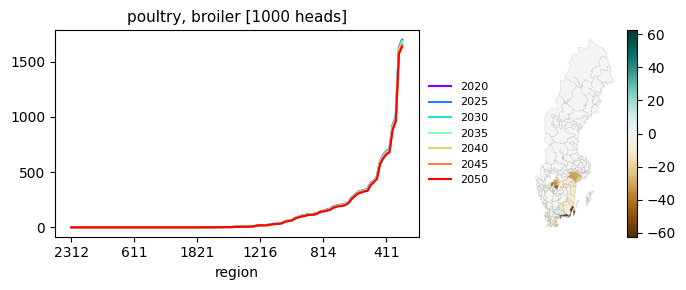

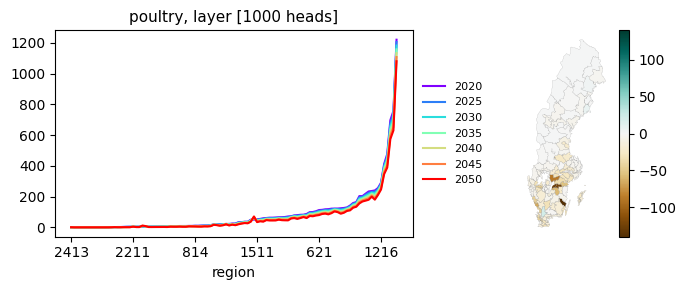

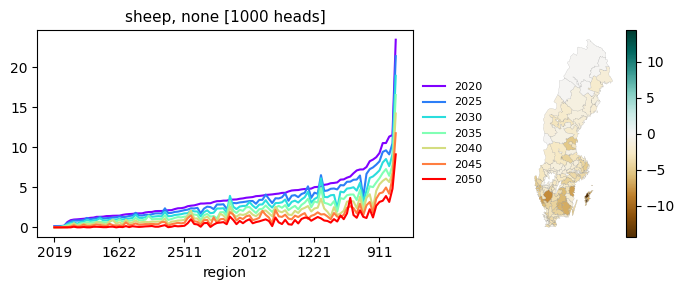

In [55]:
for scn in session.scenarios():
    print(scn)
    print('-'*len(scn))
    plot_data_ = session.get_attr('A','heads',['species','breed','region'], scn=scn).droplevel('scn').T/1000
    years = list(plot_data_.columns)

    for sp,br in plot_data_.index.droplevel('region').unique():
        plot_data = plot_data_.loc[sp,br].groupby('region').sum()
        plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
        plot_data.sort_values(by=years[0], inplace=True)
    
        fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
        ax=axs[0]
        plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
        # ax.set_yscale('log')
        ax.set_title(f'{sp}, {br} [1000 heads]', size=11)
        ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
        ax=axs[1]
        lim = max(abs(plot_data['dif']))
        plot.map_from_series(
            plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
            ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
        )
        ax.axis('off')
    
        plt.tight_layout()
        plt.show()

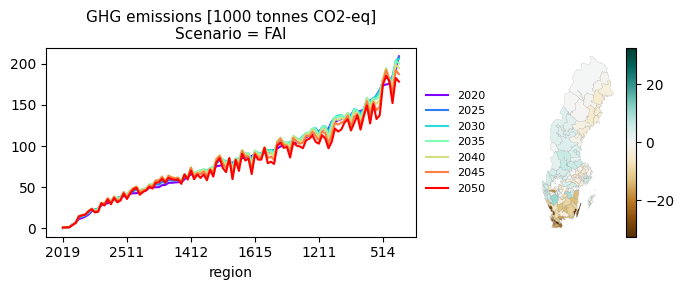

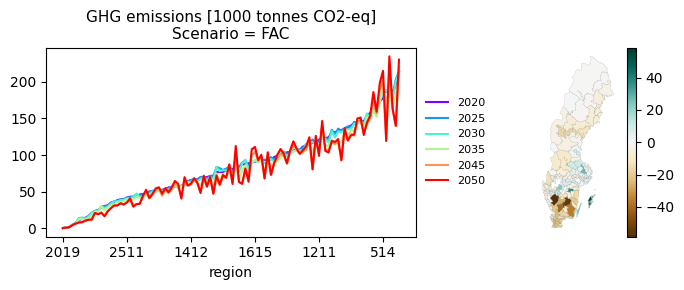

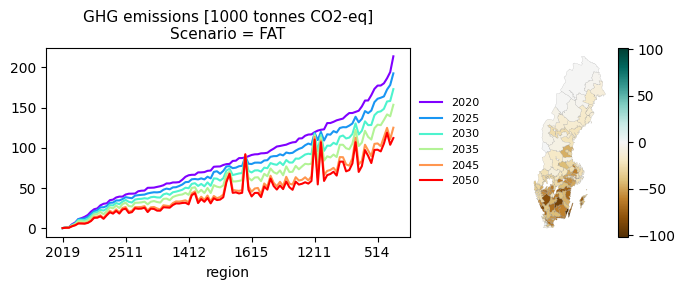

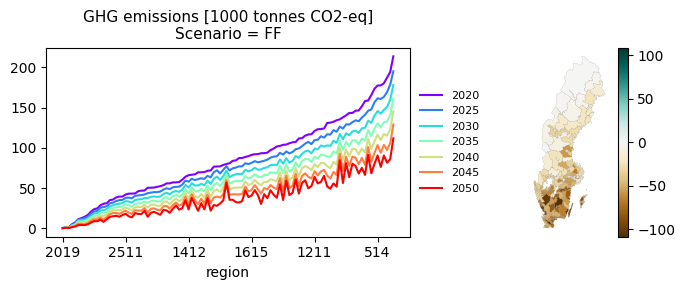

In [66]:
GHG_data = cm.get_GHG(session).T.groupby('region').sum()/1000000

for scn in session.scenarios():
    
    plot_data = GHG_data.loc[:,scn].copy()
    years = list(plot_data.columns)
    plot_data['dif'] = (plot_data[years[-1]]-plot_data[years[0]])
    plot_data.sort_values(by=years[0], inplace=True)
    
    fig, axs = plt.subplots(1,2, figsize=(7,3), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(ax=ax, y=years, kind='line', marker='', linestyle='-', cmap='rainbow')
    # ax.set_yscale('log')
    ax.set_title(f'GHG emissions [1000 tonnes CO2-eq]\nScenario = {scn}', size=11)
    ax.legend(loc='center left', ncols=1, bbox_to_anchor=(1, 0.5), frameon=False, fontsize=8)
    
    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()